In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

### Functions for Calculation Centralities

In [2]:
# Weighted Closeness Centrality
def weighted_closeness(G):
    nodes = list(G.nodes())
    closeness = []
    for i in range(0, len(nodes)):
        close = []
        dist_ij = 0
        for j in range(0, len(nodes)):
            if(nodes[i] == nodes[j]):
                    continue
            else:
                wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[i], target=nodes[j], weight='weight')
                dist_ij = dist_ij + wt
        closeness_i = 1 / dist_ij
        close.append(nodes[i])
        close.append(closeness_i)
        closeness.append(close)
    return closeness

# Weighted Betweenness Centrality
def weighted_betweenness(G):
    nodes = list(G.nodes())
    betweenness = []
    for n in range(0, len(nodes)):
        bett = []
        dist_n = 0
        dist_v = 0
        for s in range(0, len(nodes)):
            for t in range(s+1, len(nodes)):
                if(nodes[n] == nodes[s] or nodes[n] == nodes[t] or nodes[s] == nodes[t]):
                    continue
                else:
                    wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[s], target=nodes[t], weight='weight')
                    if(nodes[n] in s_path):
                        dist_n = dist_n + wt
                    dist_v = dist_v + wt
        betweenness_n = dist_n / dist_v
        bett.append(nodes[n])
        bett.append(betweenness_n)
        betweenness.append(bett)
    return betweenness

# Weighted Edge Contribution Factor
def weighted_ECF(G, W):
    nodes = list(G.nodes())
    ecf = []
    for i in range(0, len(nodes)):
        ecf_ = []
        w_ij = 0
        w_jk = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for n in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[n])
            val = w_['weight']
            w_ij = w_ij + val
        nbunch = neighbours_i
        common_neighbours = G.edges(nbunch, data=True)
        common_neighbours = list(common_neighbours)
        for j in range(0, len(common_neighbours)):
            if((common_neighbours[j][0] == nodes[i]) or (common_neighbours[j][1] == nodes[i])):
                continue
            elif(((common_neighbours[j][0] in neighbours_i) == False) or ((common_neighbours[j][1] in neighbours_i) == False )):
                continue
            else:
                w_ = G.get_edge_data(common_neighbours[j][0], common_neighbours[j][1])
                val = w_['weight']
                w_jk = w_jk + val            
            
        w_ecf = (w_ij + w_jk) / W
        ecf_.append(nodes[i])
        ecf_.append(w_ecf)
        ecf.append(ecf_)
    return ecf

def degree(G,W):
    nodes = list(G.nodes())
    w_degree = []
    for i in range(0, len(nodes)):
        deg = []
        nd = nodes[i]
        m_dg = modi_deg(G,nd,W)
        deg.append(nd)
        deg.append(m_dg)
        w_degree.append(deg)
    return w_degree

# New One
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        closeness.append(nd)
        closeness.append(weight)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### Loading Dataset and Create the Network and its Visualization

### lw_n_1

Name: 
Type: Graph
Number of nodes: 14
Number of edges: 25
Average degree:   3.5714


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


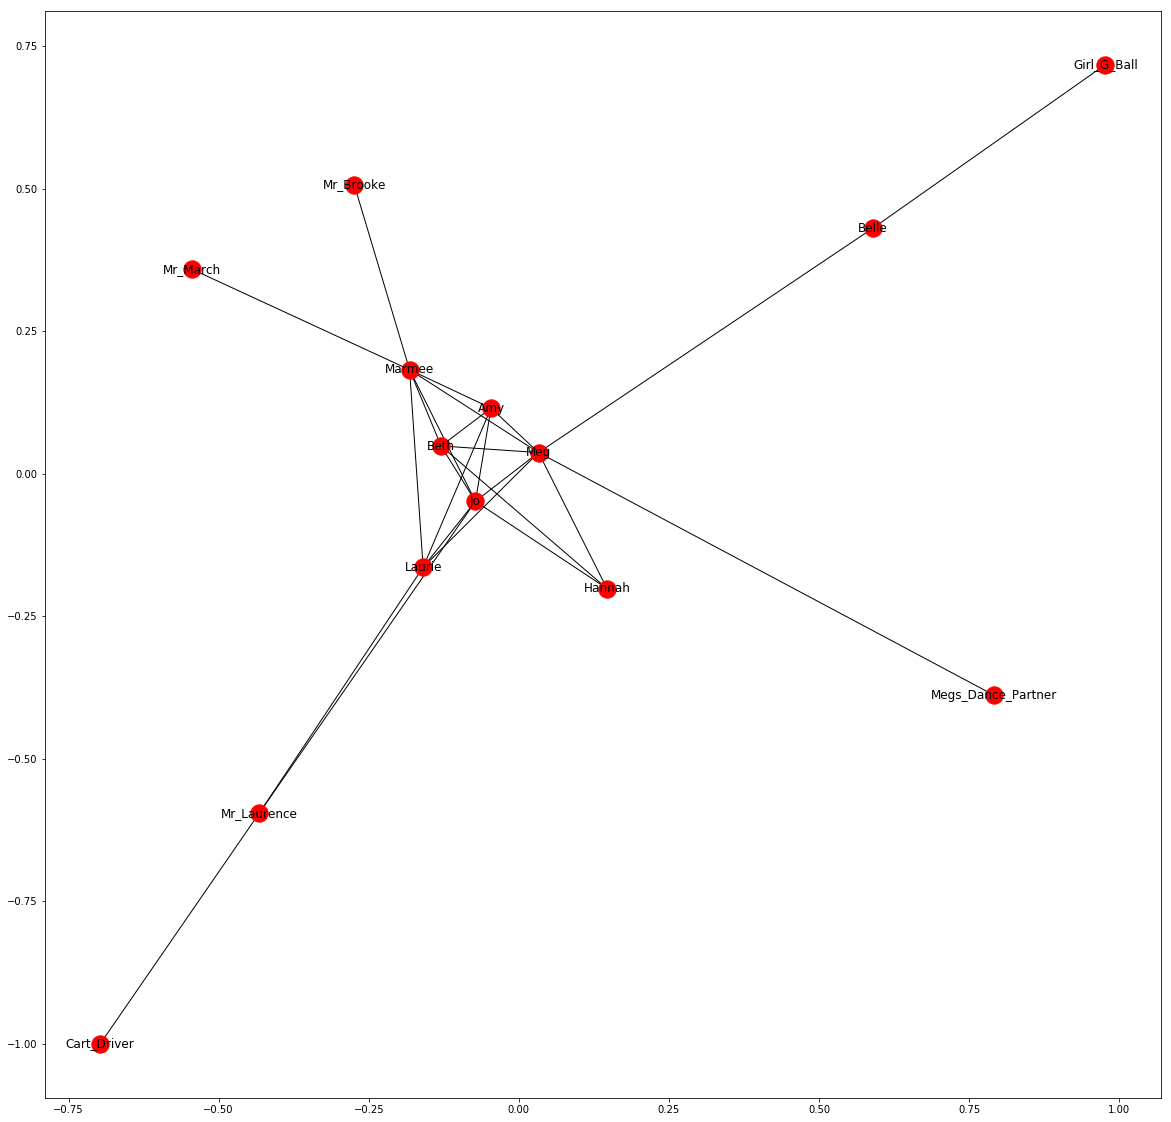

                 Nodes  Degree       ECF       NCF
0                 Beth   101.0  0.752941  0.116028
1               Marmee    98.0  0.927059  0.113666
2                   Jo   223.0  0.936471  0.260501
3                  Amy   131.0  0.887059  0.151942
4                  Meg   166.0  0.934118  0.193916
5             Mr_March     7.0  0.016471  0.001899
6               Hannah    16.0  0.324706  0.016299
7          Mr_Laurence     8.0  0.157647  0.005403
8               Laurie    77.0  0.665882  0.089522
9          Cart_Driver     3.0  0.007059  0.000066
10               Belle     6.0  0.014118  0.002807
11         Girl_G_Ball     3.0  0.007059  0.000050
12  Megs_Dance_Partner     1.0  0.002353  0.000460
13           Mr_Brooke    10.0  0.023529  0.002713
      Degree       ECF       NCF
0   0.290710  0.353466  0.287158
1   0.282075  0.435205  0.281314
2   0.641865  0.439624  0.644716
3   0.377060  0.416427  0.376042
4   0.477801  0.438519  0.479923
5   0.020148  0.007732  0.004700
6   

In [3]:
lw_1 = nx.read_weighted_edgelist('lw_m_1.txt', delimiter=',')
print(nx.info(lw_1))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_1)
plt.show()

#Weighted Centralities
w_deg = lw_1.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_1)  #ECF
w_ecf = weighted_ECF(lw_1, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_1) #NCF
w_ncf = weighted_cness(lw_1,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [4]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.291,0.353,0.287
1,0.282,0.435,0.281
2,0.642,0.440,0.645
3,0.377,0.416,0.376
4,0.478,0.439,0.480
5,0.020,0.008,0.005
6,0.046,0.152,0.040
7,0.023,0.074,0.013
8,0.222,0.313,0.222
9,0.009,0.003,0.000


Text(0, 0.5, 'Values')

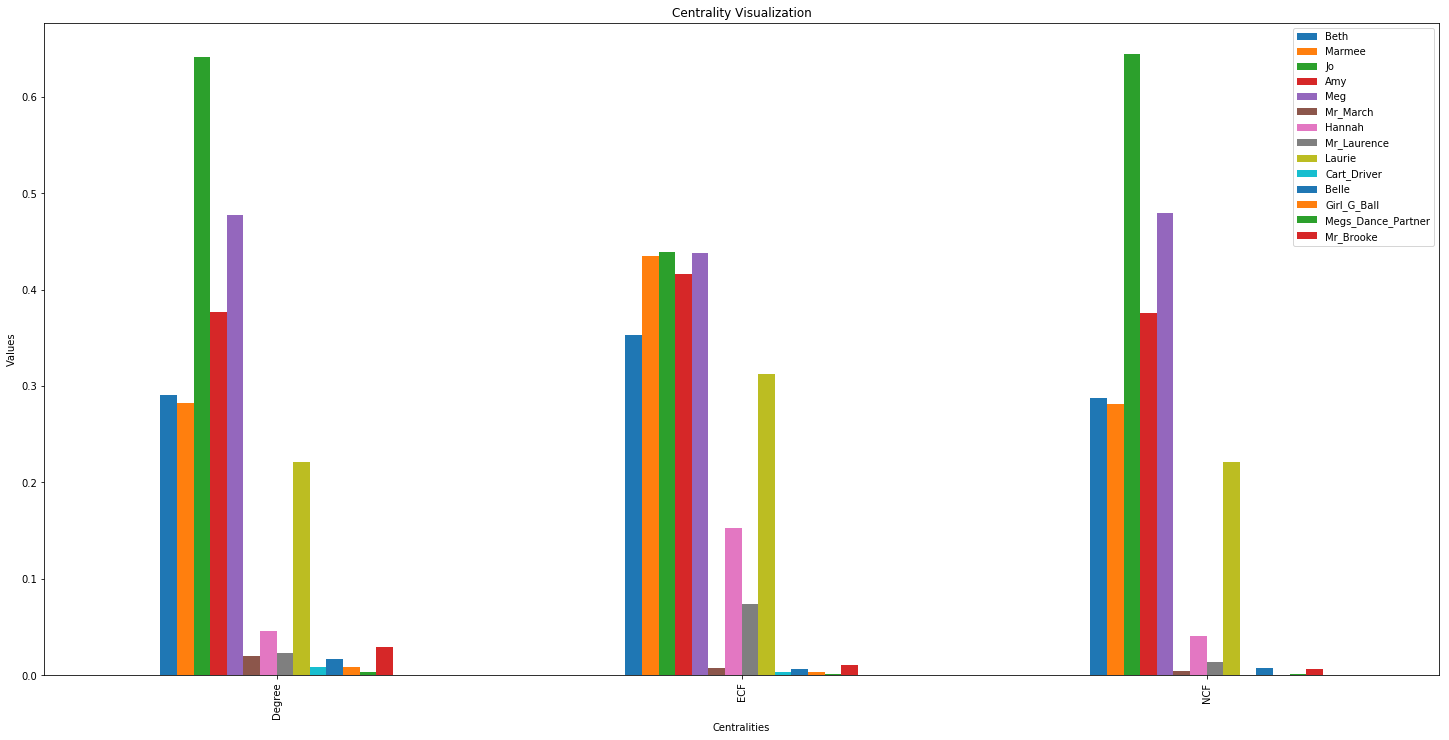

In [4]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

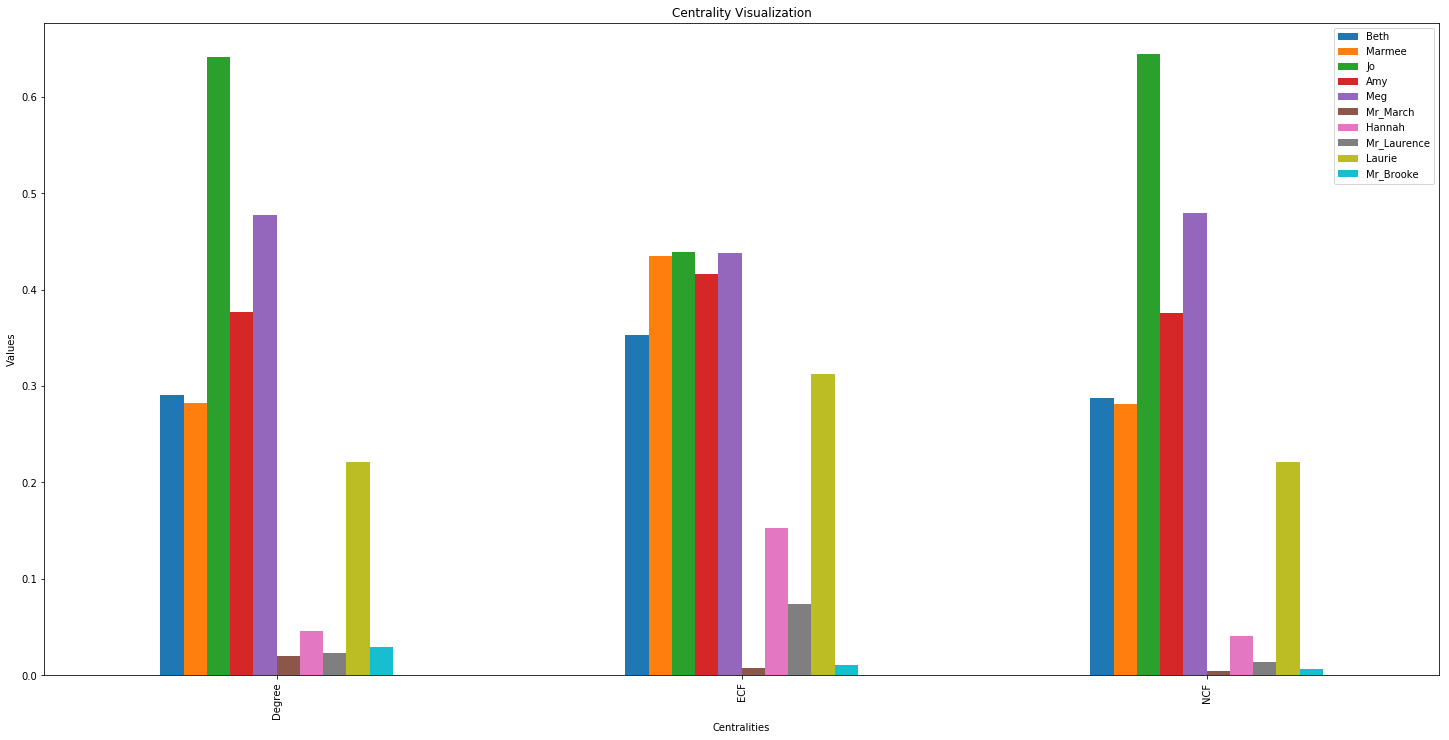

In [5]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

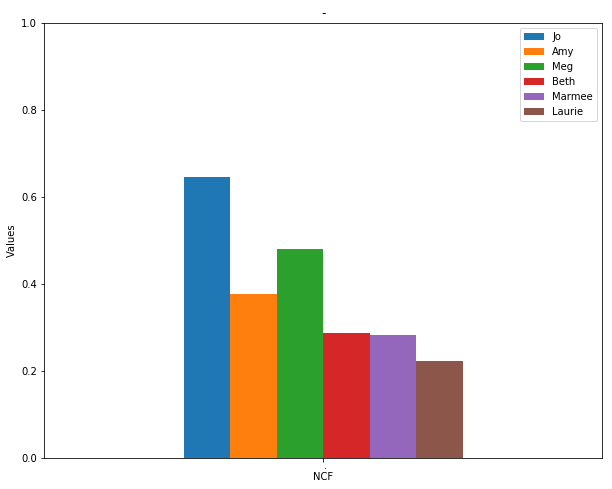

In [6]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_2

Name: 
Type: Graph
Number of nodes: 20
Number of edges: 41
Average degree:   4.1000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


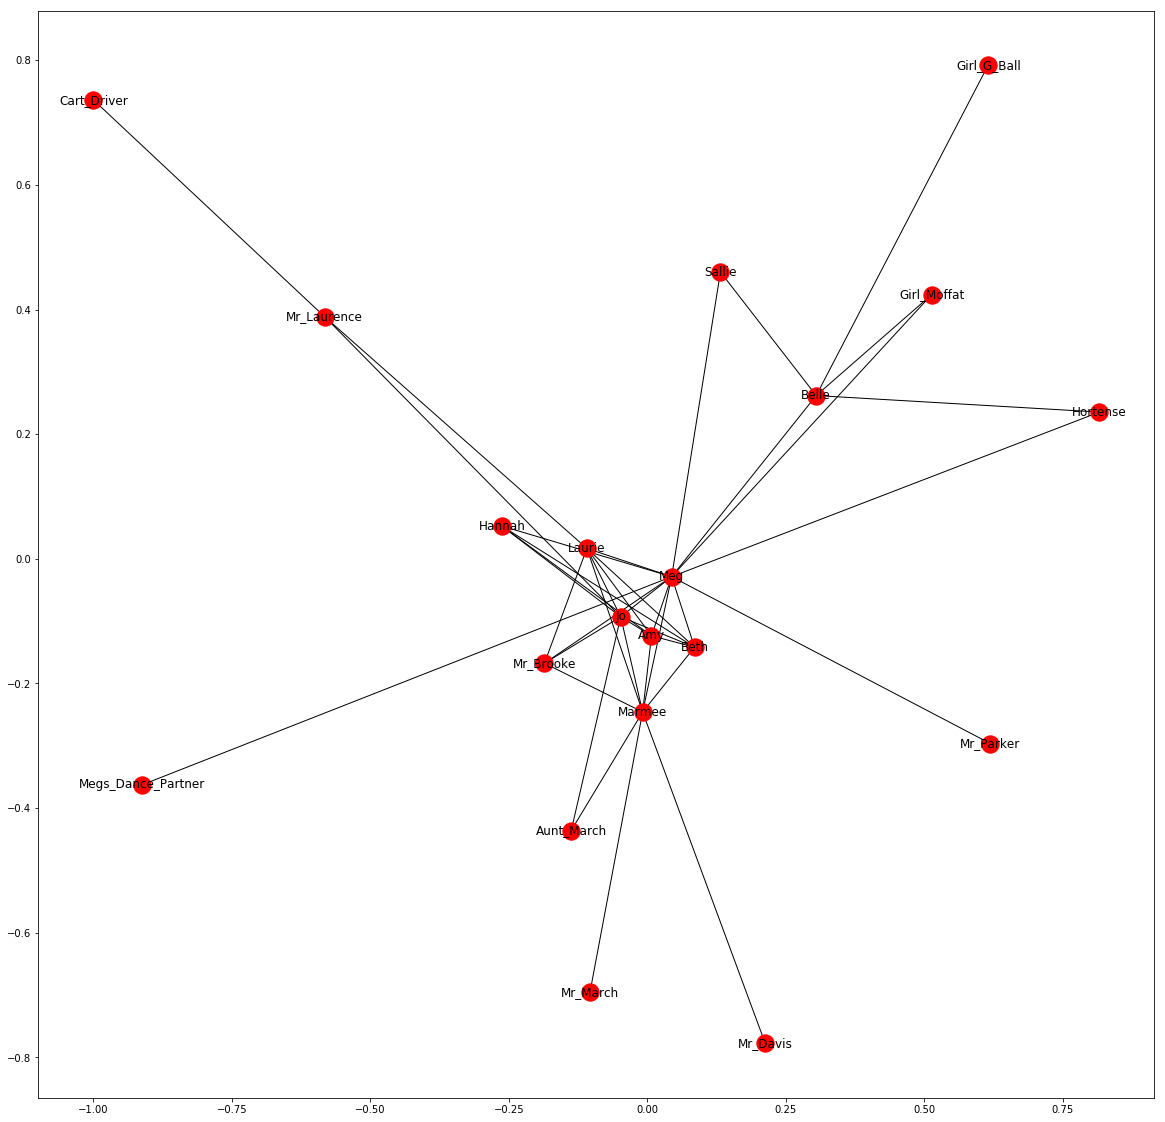

                 Nodes  Degree       ECF       NCF
0                 Beth   146.0  0.861628  0.083206
1               Marmee   200.0  0.918605  0.113981
2                   Jo   457.0  0.934884  0.262608
3                  Amy   288.0  0.861628  0.164132
4                  Meg   332.0  0.948837  0.192350
5             Mr_March     7.0  0.008140  0.000946
6               Hannah    20.0  0.520930  0.010749
7          Mr_Laurence     8.0  0.103488  0.002812
8               Laurie   141.0  0.886047  0.080642
9          Cart_Driver     3.0  0.003488  0.000016
10               Belle    31.0  0.044186  0.007251
11         Girl_G_Ball     3.0  0.003488  0.000063
12  Megs_Dance_Partner     1.0  0.001163  0.000224
13           Mr_Brooke    36.0  0.417442  0.019640
14          Aunt_March    22.0  0.093023  0.008909
15            Mr_Davis     4.0  0.004651  0.000541
16              Sallie     9.0  0.030233  0.002105
17         Girl_Moffat     6.0  0.026744  0.001403
18            Hortense     3.0 

In [5]:
lw_2 = nx.read_weighted_edgelist('lw_m_2.txt', delimiter=',')
print(nx.info(lw_2))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_2)
plt.show()

#Weighted Centralities
w_deg = lw_2.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_2)  #ECF
w_ecf = weighted_ECF(lw_2, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_2) #NCF
w_ncf = weighted_cness(lw_2,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [6]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.209,0.372,0.208
1,0.287,0.397,0.285
2,0.655,0.404,0.657
3,0.413,0.372,0.410
4,0.476,0.410,0.481
5,0.010,0.004,0.002
6,0.029,0.225,0.027
7,0.011,0.045,0.007
8,0.202,0.383,0.202
9,0.004,0.002,0.000


Text(0, 0.5, 'Values')

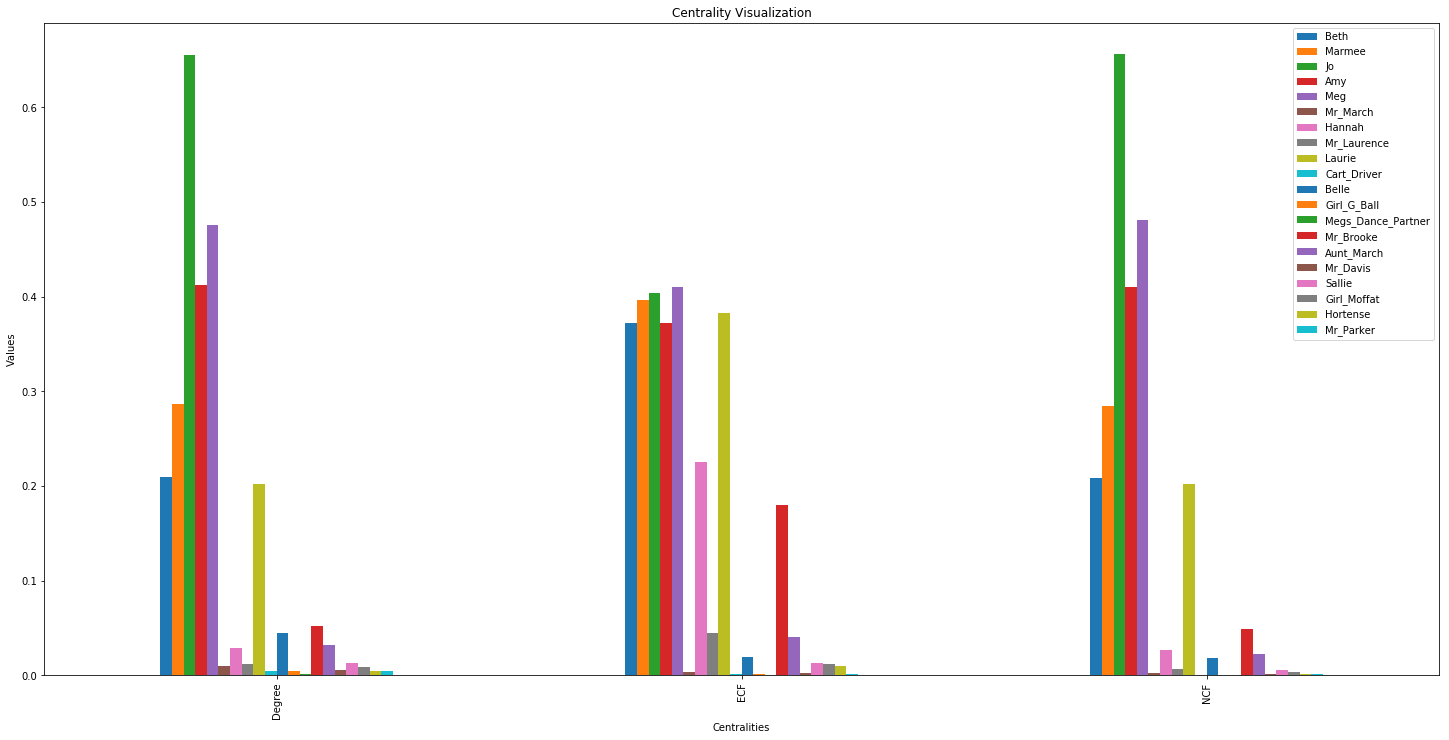

In [8]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

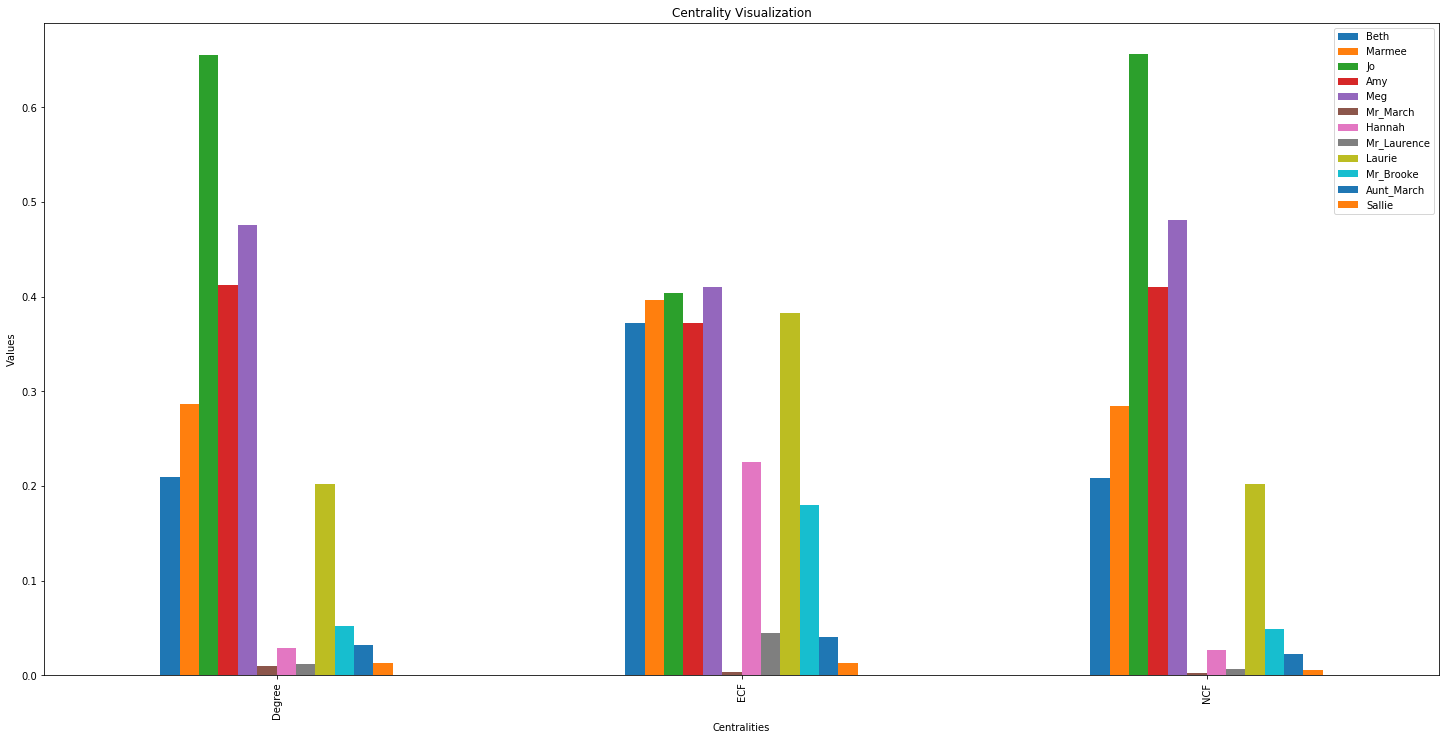

In [9]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

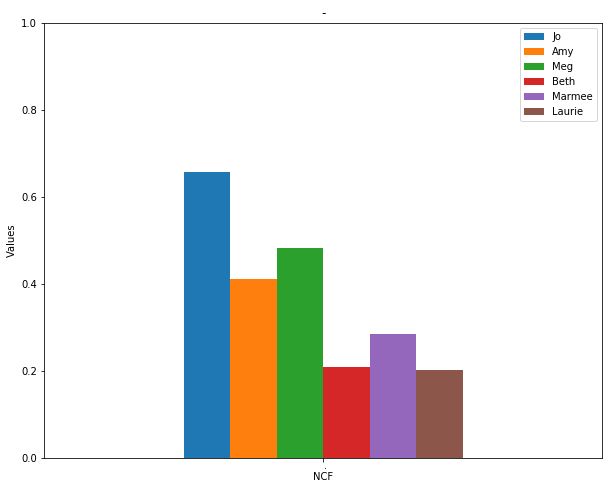

In [10]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_3

Name: 
Type: Graph
Number of nodes: 20
Number of edges: 42
Average degree:   4.2000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


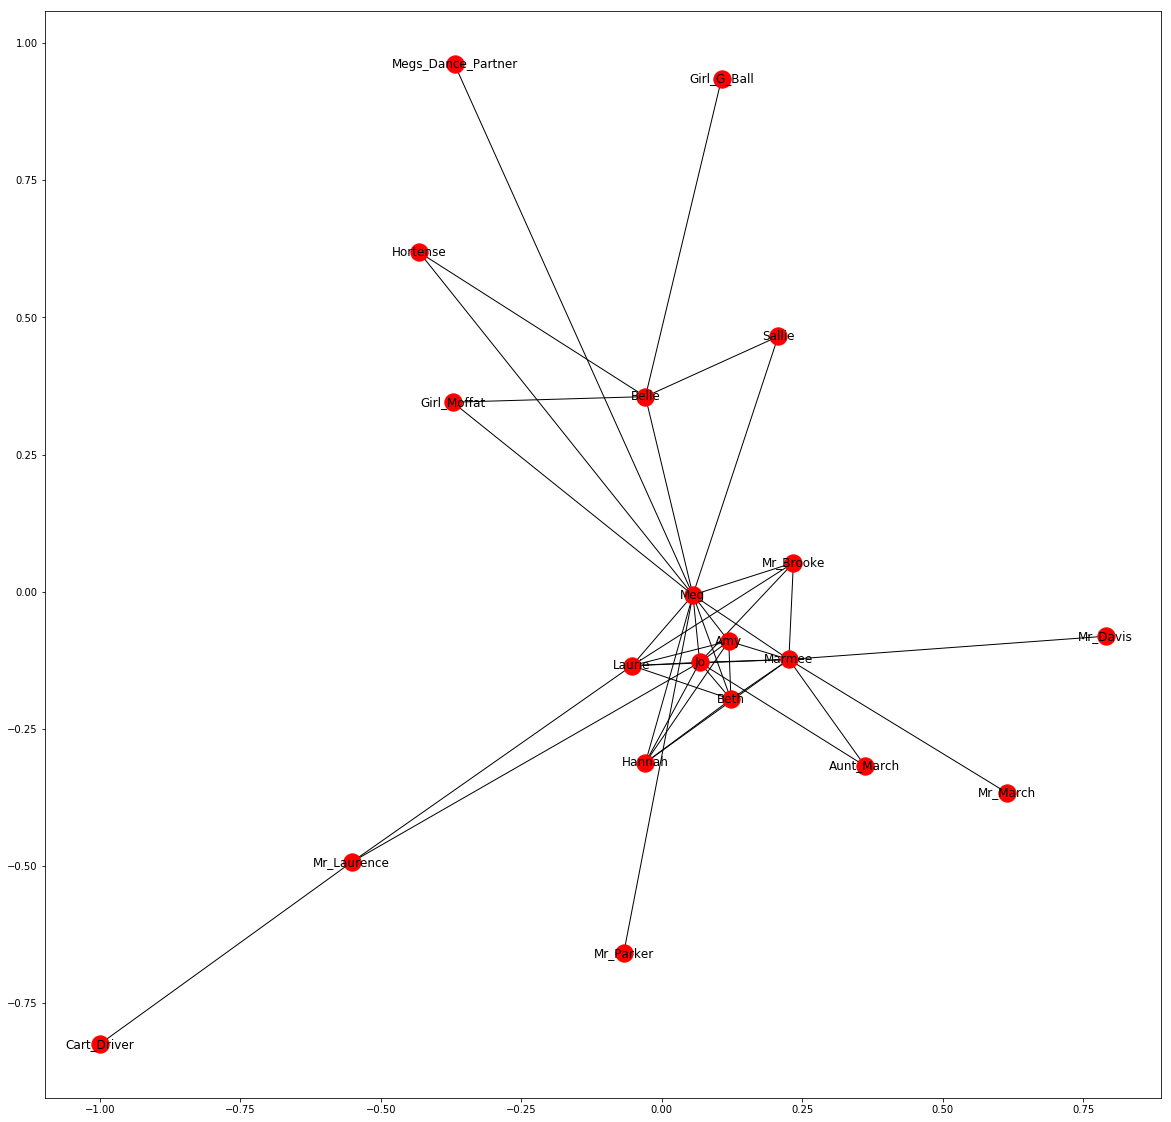

                 Nodes  Degree       ECF       NCF
0                 Beth   157.0  0.861345  0.080986
1               Marmee   244.0  0.947479  0.125863
2                   Jo   507.0  0.941176  0.264044
3                  Amy   301.0  0.861345  0.155265
4                  Meg   355.0  0.953782  0.185862
5             Mr_March     7.0  0.007353  0.000942
6               Hannah    28.0  0.697479  0.014335
7          Mr_Laurence     8.0  0.115546  0.002520
8               Laurie   163.0  0.888655  0.084350
9          Cart_Driver     3.0  0.003151  0.000013
10               Belle    31.0  0.039916  0.006311
11         Girl_G_Ball     3.0  0.003151  0.000051
12  Megs_Dance_Partner     1.0  0.001050  0.000196
13           Mr_Brooke    49.0  0.445378  0.024167
14          Aunt_March    22.0  0.096639  0.008265
15            Mr_Davis     4.0  0.004202  0.000538
16              Sallie     9.0  0.027311  0.001832
17         Girl_Moffat     6.0  0.024160  0.001221
18            Hortense     3.0 

In [7]:
lw_3 = nx.read_weighted_edgelist('lw_m_3.txt', delimiter=',')
print(nx.info(lw_3))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_3)
plt.show()

#Weighted Centralities
w_deg = lw_3.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_3)  #ECF
w_ecf = weighted_ECF(lw_3, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_3) #NCF
w_ncf = weighted_cness(lw_3,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [8]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.205,0.361,0.203
1,0.318,0.398,0.316
2,0.660,0.395,0.663
3,0.392,0.361,0.390
4,0.462,0.400,0.466
5,0.009,0.003,0.002
6,0.036,0.293,0.036
7,0.010,0.048,0.006
8,0.212,0.373,0.212
9,0.004,0.001,0.000


Text(0, 0.5, 'Values')

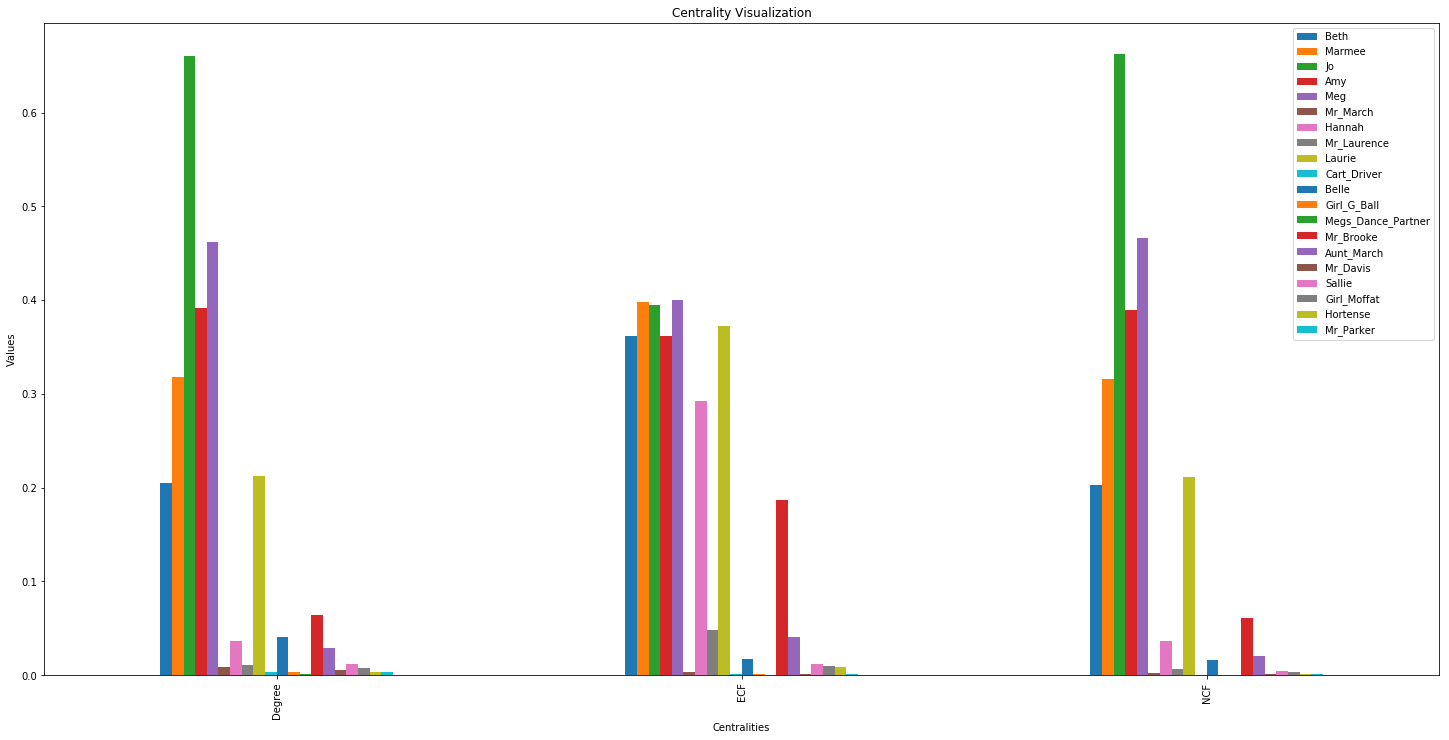

In [12]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

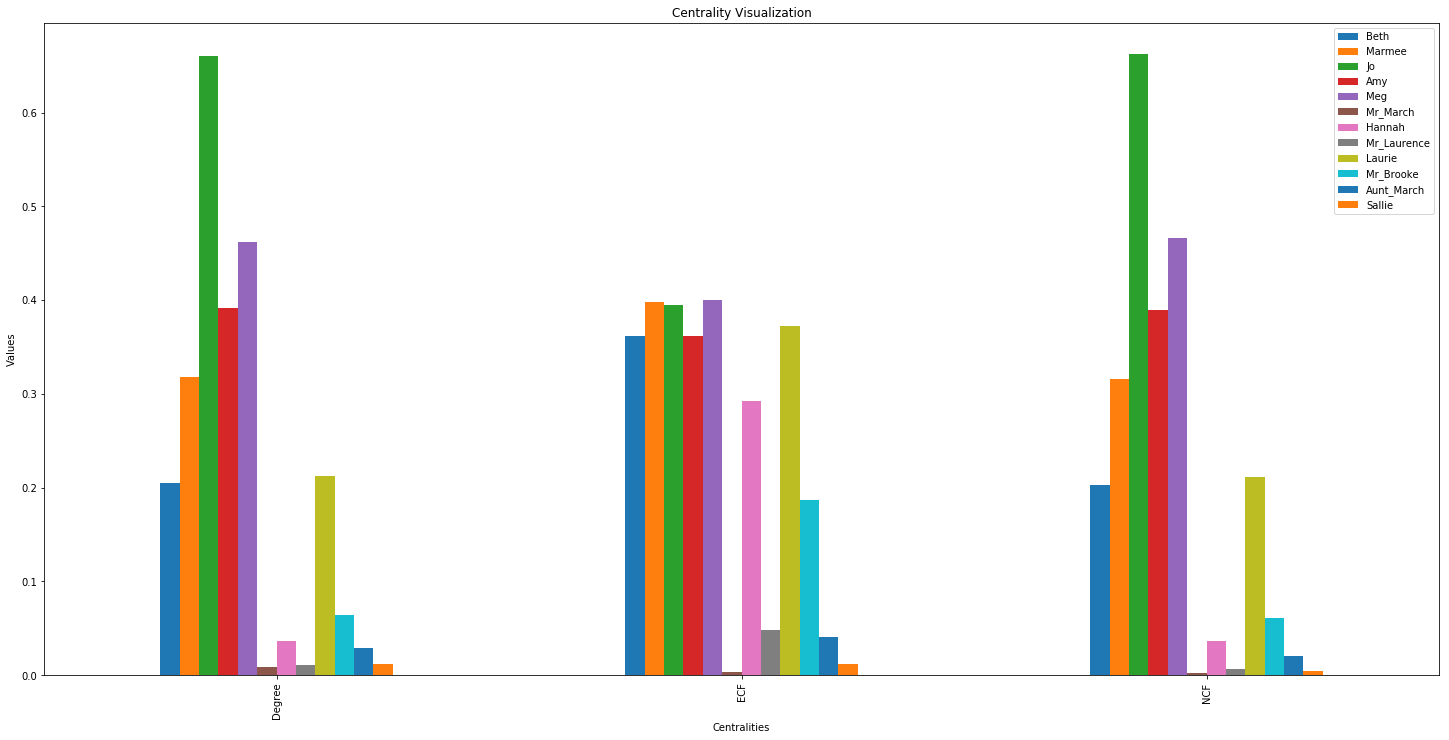

In [13]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

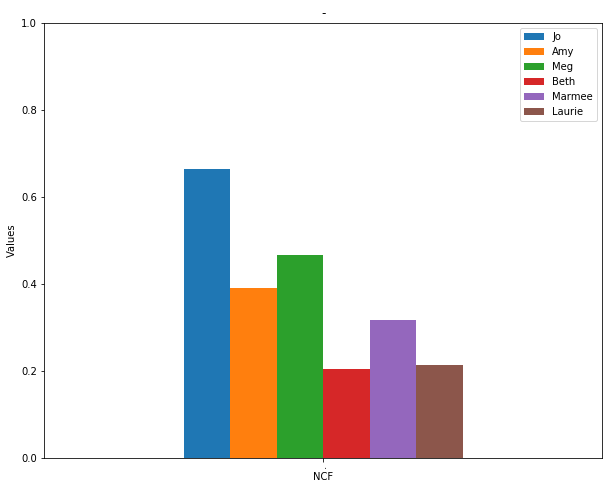

In [14]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_4

Name: 
Type: Graph
Number of nodes: 23
Number of edges: 48
Average degree:   4.1739


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


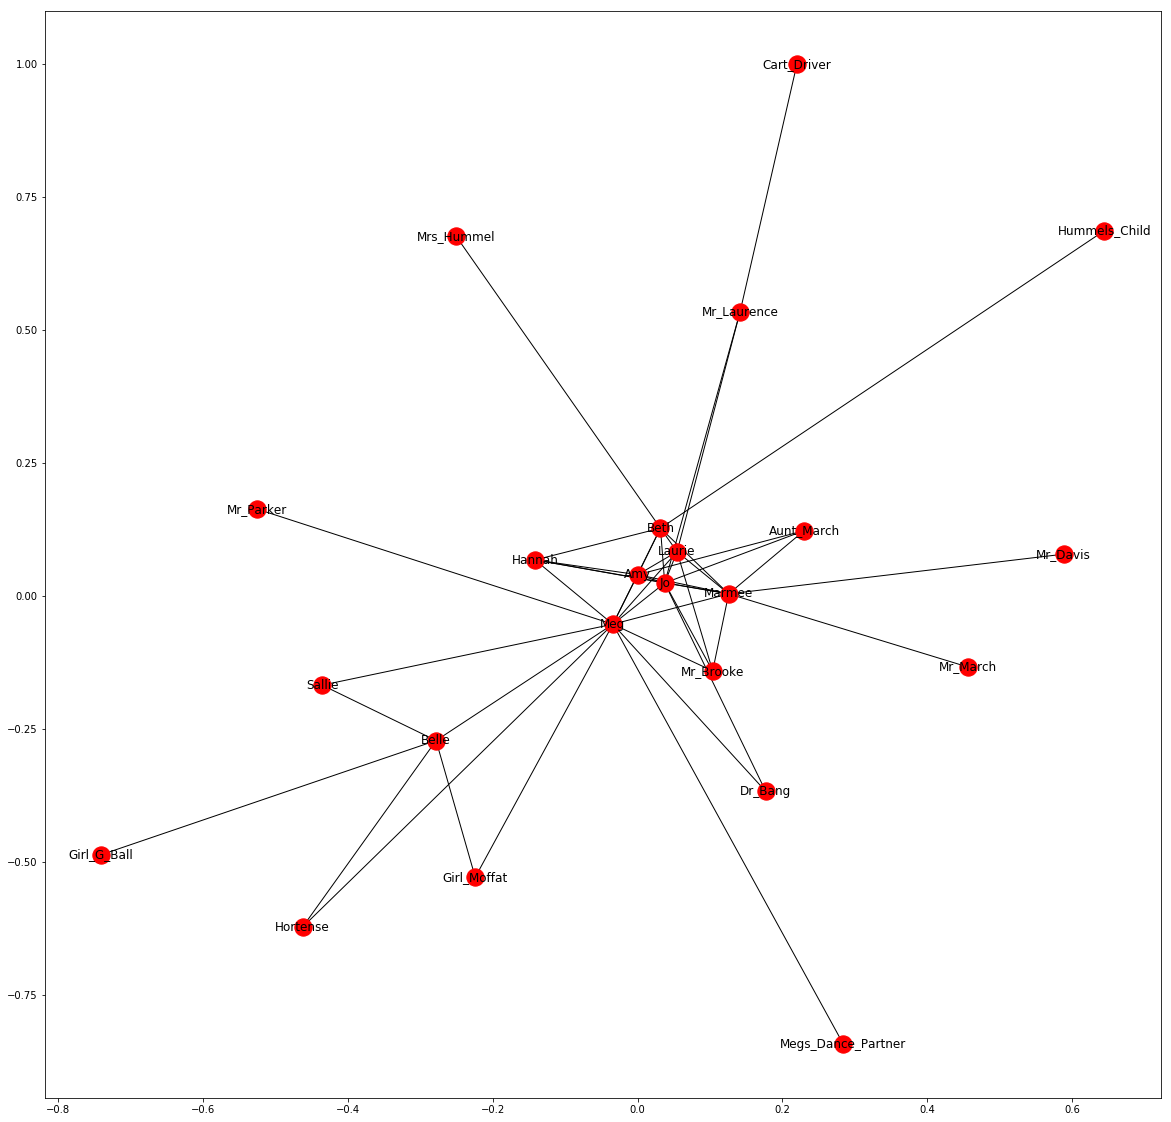

                 Nodes  Degree       ECF       NCF
0                 Beth   180.0  0.863383  0.082322
1               Marmee   256.0  0.944238  0.117080
2                   Jo   562.0  0.945167  0.259453
3                  Amy   355.0  0.888476  0.162816
4                  Meg   403.0  0.947955  0.186746
5             Mr_March     7.0  0.006506  0.000774
6               Hannah    40.0  0.691450  0.018173
7          Mr_Laurence     9.0  0.106877  0.002519
8               Laurie   189.0  0.874535  0.086683
9          Cart_Driver     3.0  0.002788  0.000012
10               Belle    31.0  0.035316  0.005583
11         Girl_G_Ball     3.0  0.002788  0.000040
12  Megs_Dance_Partner     1.0  0.000929  0.000174
13           Mr_Brooke    49.0  0.427509  0.021140
14          Aunt_March    30.0  0.274164  0.011764
15            Mr_Davis     4.0  0.003717  0.000442
16              Sallie     9.0  0.024164  0.001621
17         Girl_Moffat     6.0  0.021375  0.001081
18            Hortense     3.0 

In [9]:
lw_4 = nx.read_weighted_edgelist('lw_m_4.txt', delimiter=',')
print(nx.info(lw_4))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_4)
plt.show()

#Weighted Centralities
w_deg = lw_4.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_4)  #ECF
w_ecf = weighted_ECF(lw_4, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_4) #NCF
w_ncf = weighted_cness(lw_4,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [10]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.209,0.360,0.207
1,0.297,0.394,0.295
2,0.651,0.394,0.653
3,0.412,0.370,0.410
4,0.467,0.395,0.470
5,0.008,0.003,0.002
6,0.046,0.288,0.046
7,0.010,0.045,0.006
8,0.219,0.365,0.218
9,0.003,0.001,0.000


Text(0, 0.5, 'Values')

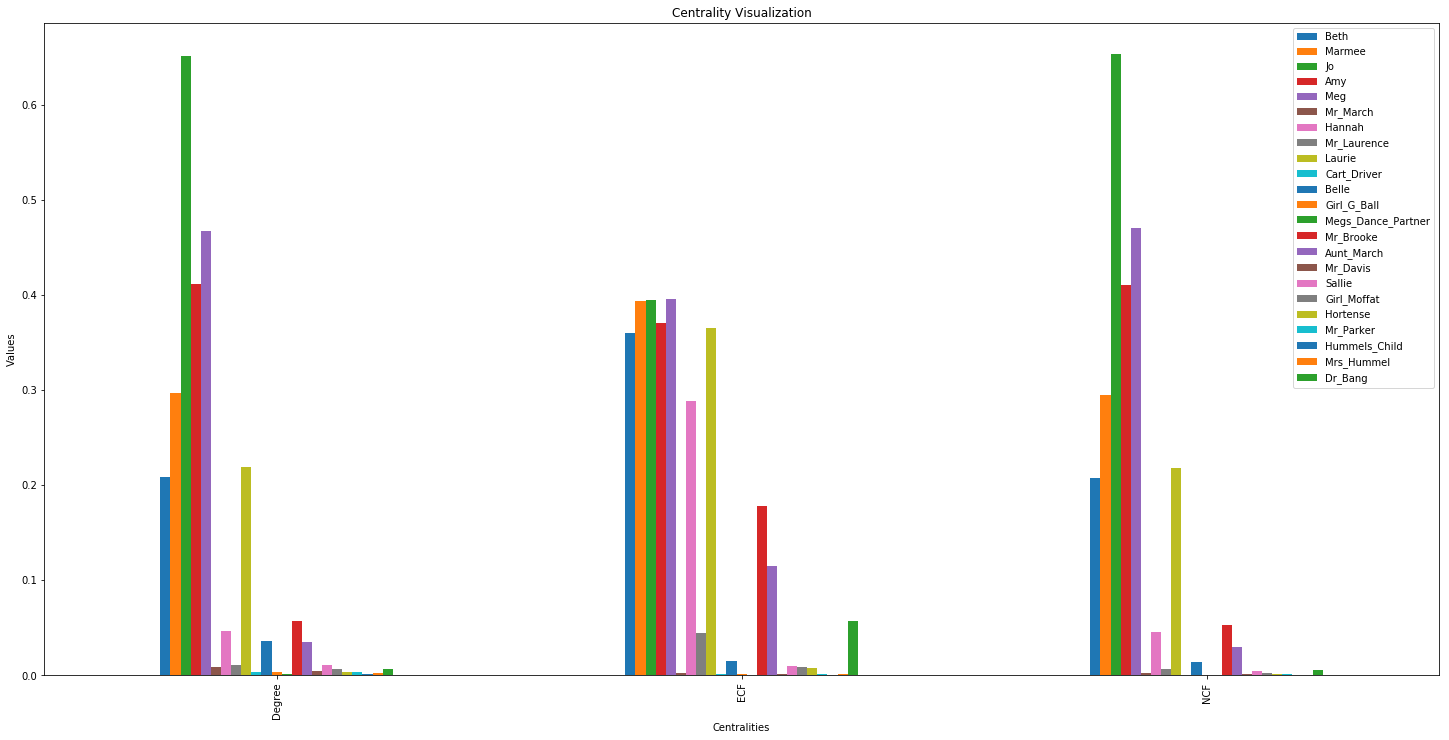

In [16]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19]),
    "Hummels_Child":list(df_2.loc[20]),
    "Mrs_Hummel":list(df_2.loc[21]),
    "Dr_Bang":list(df_2.loc[22])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

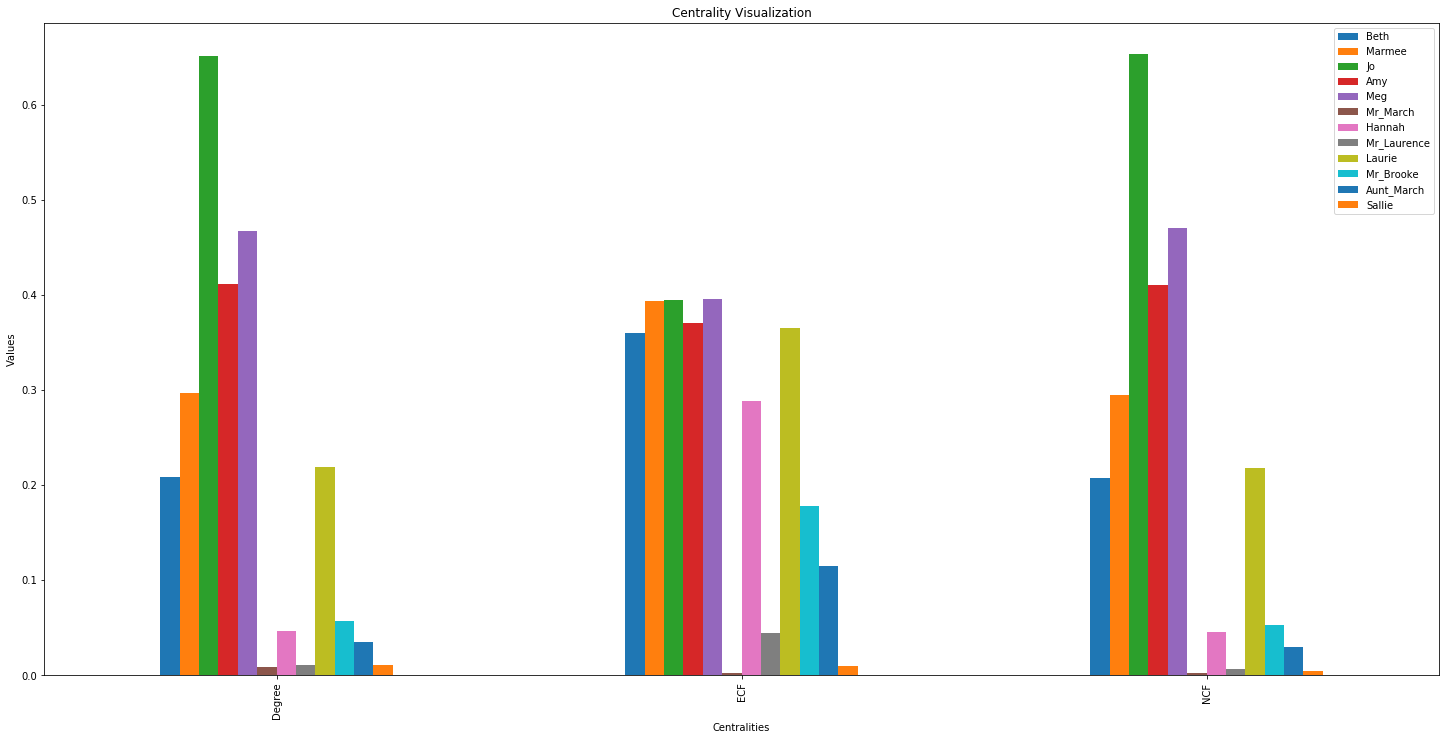

In [17]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

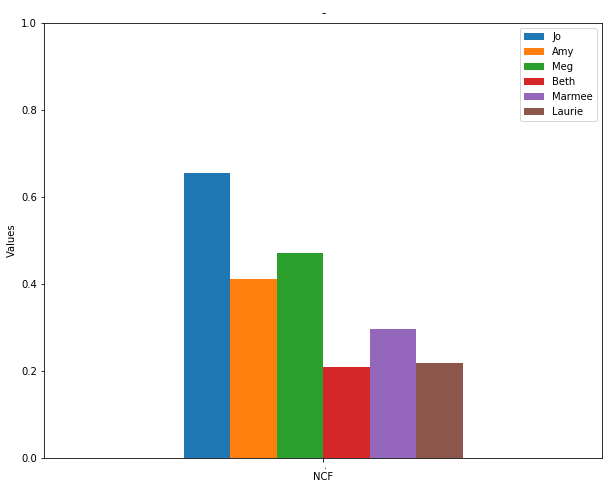

In [18]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_5

Name: 
Type: Graph
Number of nodes: 25
Number of edges: 72
Average degree:   5.7600


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


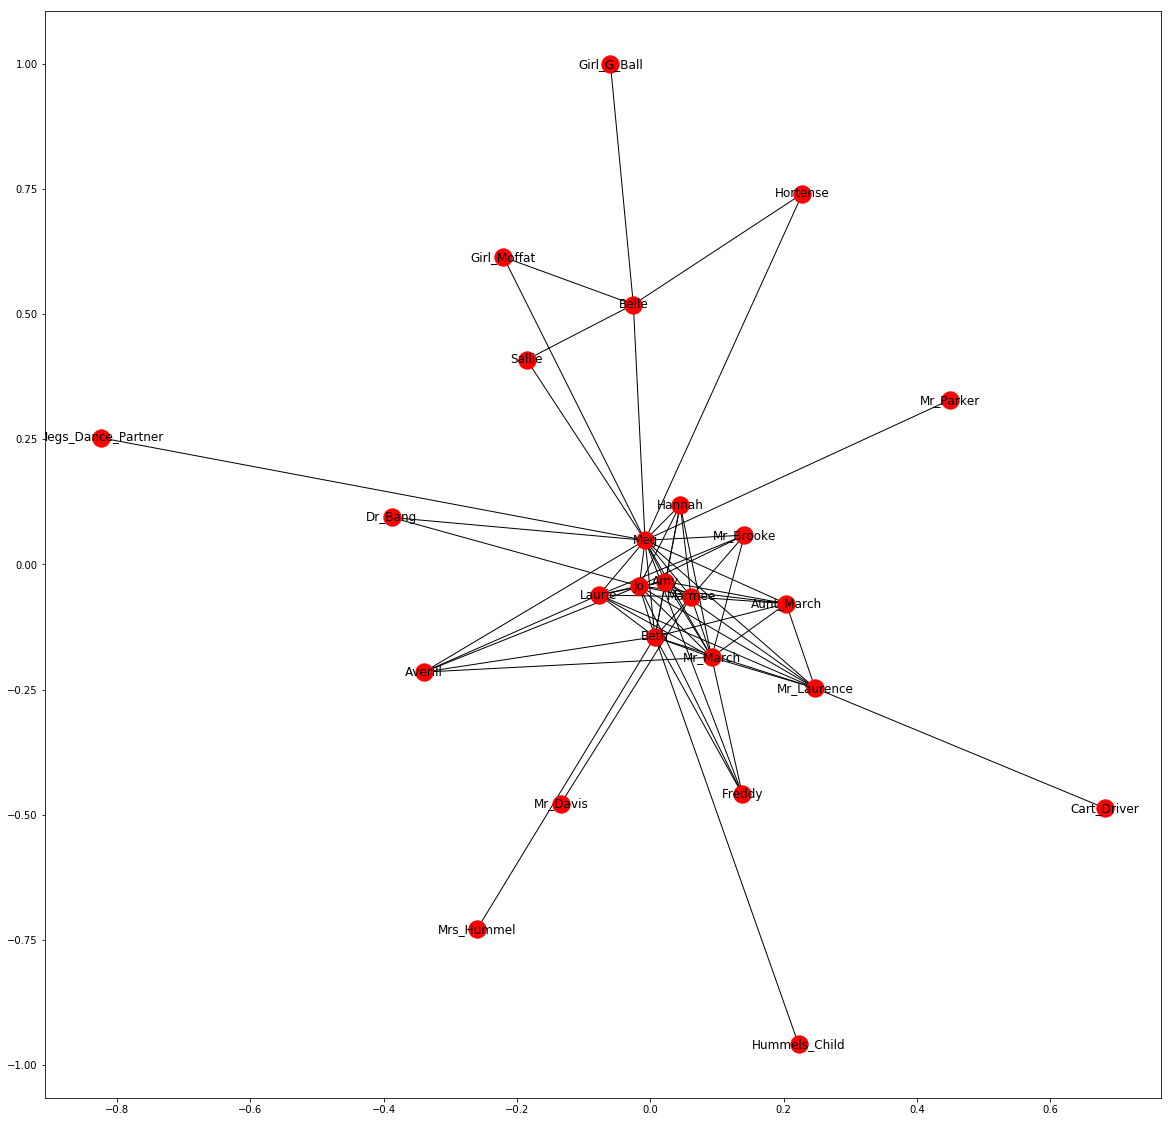

                 Nodes  Degree       ECF       NCF
0                 Beth   215.0  0.919435  0.088248
1               Marmee   287.0  0.933555  0.117503
2                   Jo   604.0  0.965116  0.249372
3                  Amy   376.0  0.905316  0.154720
4                  Meg   432.0  0.989203  0.179402
5             Mr_March    46.0  0.960133  0.018881
6               Hannah    45.0  0.690199  0.018222
7          Mr_Laurence    25.0  0.653654  0.010037
8               Laurie   204.0  0.879568  0.083733
9          Cart_Driver     3.0  0.002492  0.000026
10               Belle    21.0  0.023256  0.003231
11         Girl_G_Ball     3.0  0.002492  0.000022
12  Megs_Dance_Partner     1.0  0.000831  0.000149
13           Mr_Brooke    52.0  0.436877  0.019711
14          Aunt_March    46.0  0.704319  0.018770
15            Mr_Davis     4.0  0.003322  0.000396
16              Sallie     9.0  0.013289  0.001385
17         Girl_Moffat     6.0  0.010797  0.000923
18            Hortense     3.0 

In [11]:
lw_5 = nx.read_weighted_edgelist('lw_m_5.txt', delimiter=',')
print(nx.info(lw_5))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_5)
plt.show()

#Weighted Centralities
w_deg = lw_5.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_5)  #ECF
w_ecf = weighted_ECF(lw_5, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_5) #NCF
w_ncf = weighted_cness(lw_5,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [12]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.230,0.326,0.229
1,0.307,0.331,0.305
2,0.646,0.343,0.647
3,0.402,0.321,0.402
4,0.462,0.351,0.466
5,0.049,0.341,0.049
6,0.048,0.245,0.047
7,0.027,0.232,0.026
8,0.218,0.312,0.217
9,0.003,0.001,0.000


Text(0, 0.5, 'Values')

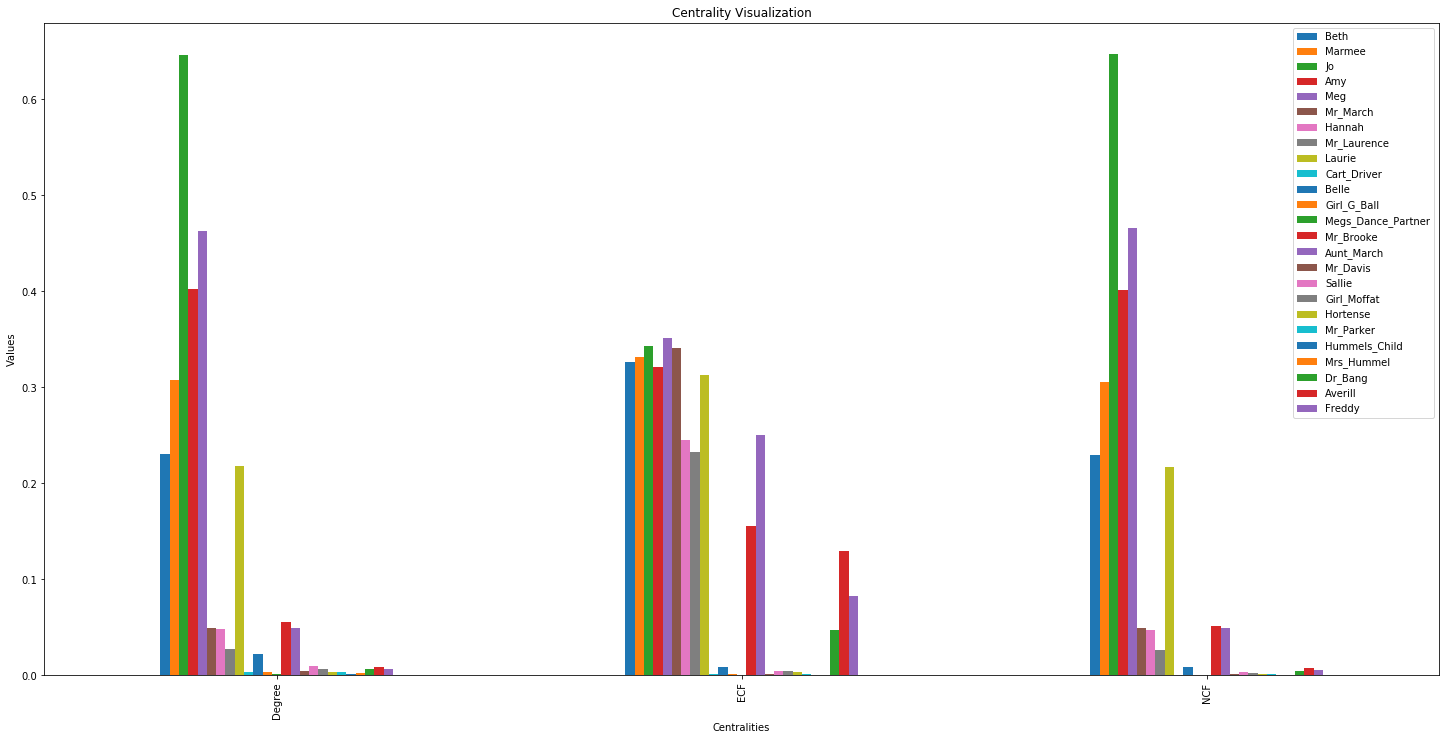

In [20]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19]),
    "Hummels_Child":list(df_2.loc[20]),
    "Mrs_Hummel":list(df_2.loc[21]),
    "Dr_Bang":list(df_2.loc[22]),
    "Averill":list(df_2.loc[23]),
    "Freddy":list(df_2.loc[24])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

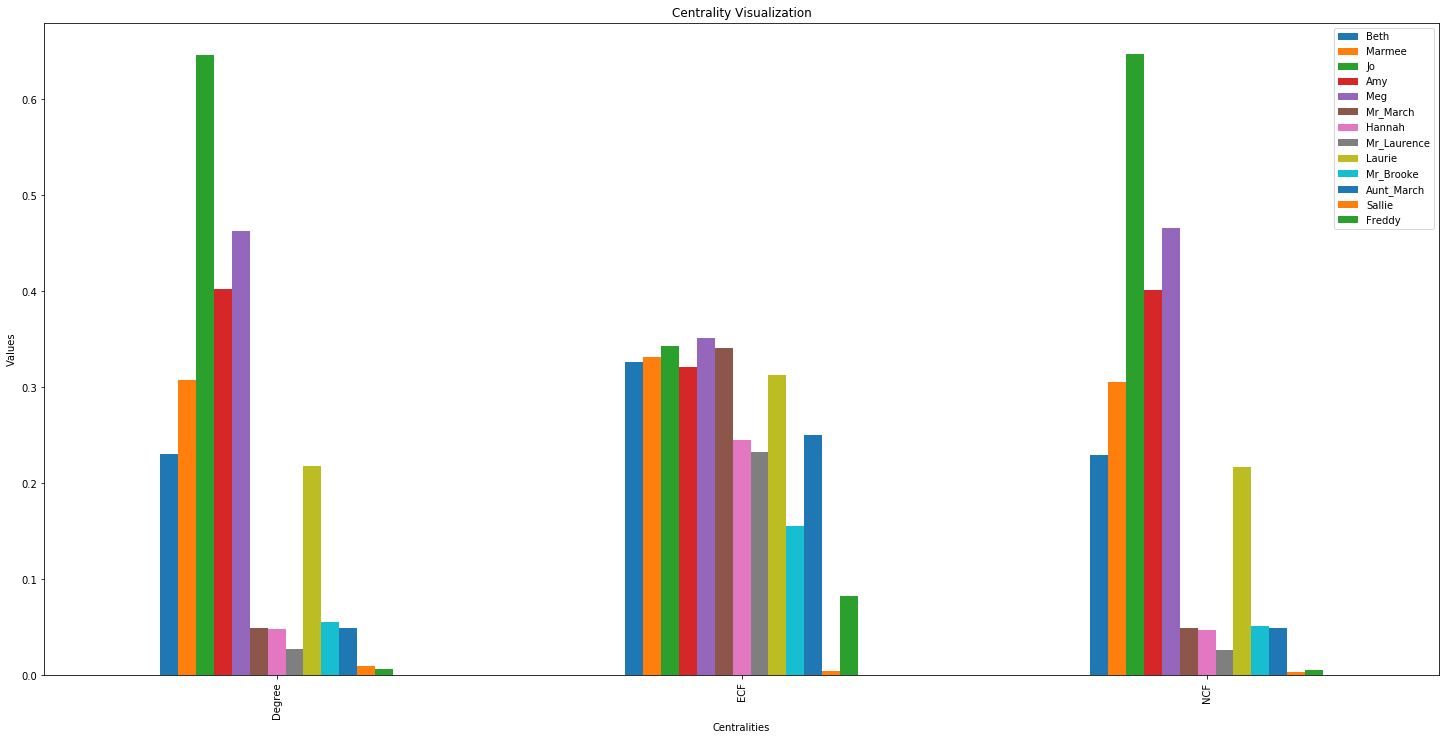

In [21]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16]),
    "Freddy":list(df_2.loc[24])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

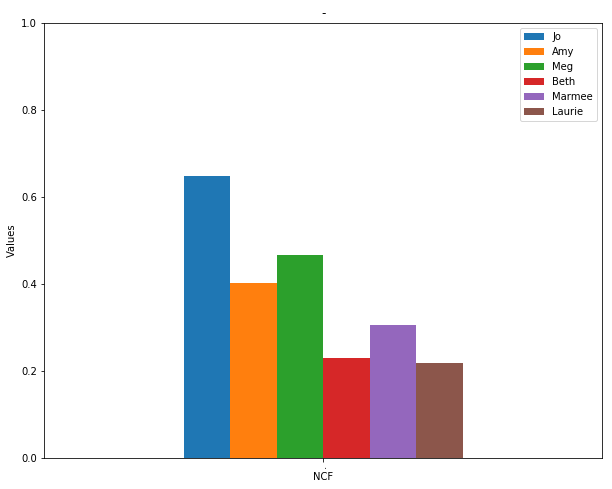

In [22]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_6

Name: 
Type: Graph
Number of nodes: 26
Number of edges: 73
Average degree:   5.6154


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


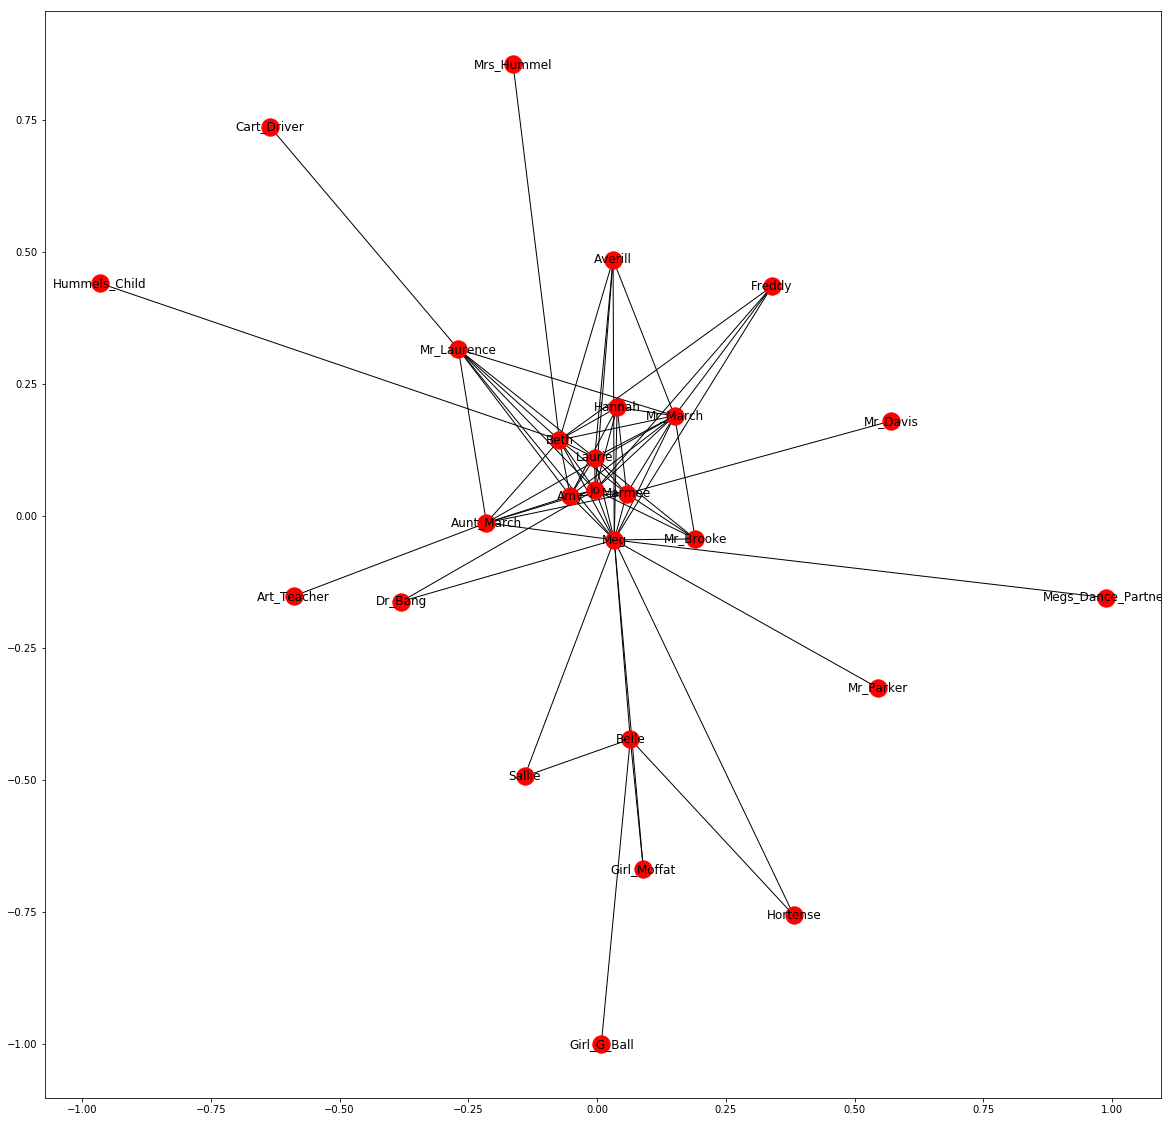

                 Nodes  Degree       ECF       NCF
0                 Beth   221.0  0.913404  0.082331
1               Marmee   305.0  0.926205  0.113364
2                   Jo   705.0  0.954819  0.264038
3                  Amy   400.0  0.900602  0.149355
4                  Meg   442.0  0.984187  0.166416
5             Mr_March    46.0  0.950301  0.017137
6               Hannah    45.0  0.658133  0.016458
7          Mr_Laurence    25.0  0.658886  0.009129
8               Laurie   267.0  0.877259  0.098862
9          Cart_Driver     3.0  0.002259  0.000021
10               Belle    31.0  0.028614  0.004008
11         Girl_G_Ball     3.0  0.002259  0.000026
12  Megs_Dance_Partner     1.0  0.000753  0.000125
13           Mr_Brooke    52.0  0.457078  0.017839
14          Aunt_March    54.0  0.676958  0.020010
15            Mr_Davis     4.0  0.003012  0.000346
16              Sallie     9.0  0.019578  0.001164
17         Girl_Moffat     6.0  0.017319  0.000776
18            Hortense     3.0 

In [13]:
lw_6 = nx.read_weighted_edgelist('lw_m_6.txt', delimiter=',')
print(nx.info(lw_6))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_6)
plt.show()

#Weighted Centralities
w_deg = lw_6.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_6)  #ECF
w_ecf = weighted_ECF(lw_6, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_6) #NCF
w_ncf = weighted_cness(lw_6,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [14]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.213,0.327,0.212
1,0.294,0.332,0.292
2,0.679,0.342,0.681
3,0.385,0.323,0.385
4,0.426,0.353,0.429
5,0.044,0.340,0.044
6,0.043,0.236,0.042
7,0.024,0.236,0.024
8,0.257,0.314,0.255
9,0.003,0.001,0.000


Text(0, 0.5, 'Values')

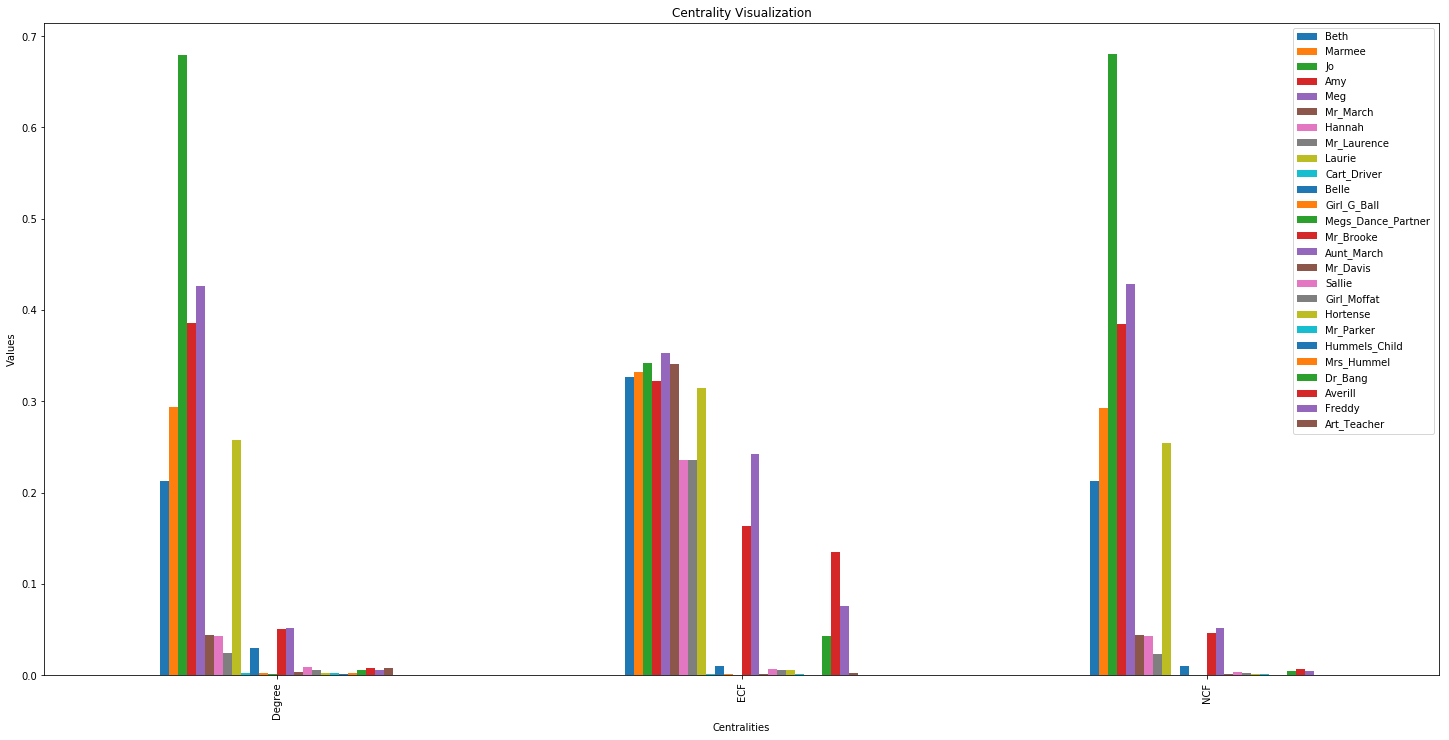

In [24]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19]),
    "Hummels_Child":list(df_2.loc[20]),
    "Mrs_Hummel":list(df_2.loc[21]),
    "Dr_Bang":list(df_2.loc[22]),
    "Averill":list(df_2.loc[23]),
    "Freddy":list(df_2.loc[24]),
    "Art_Teacher":list(df_2.loc[25])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

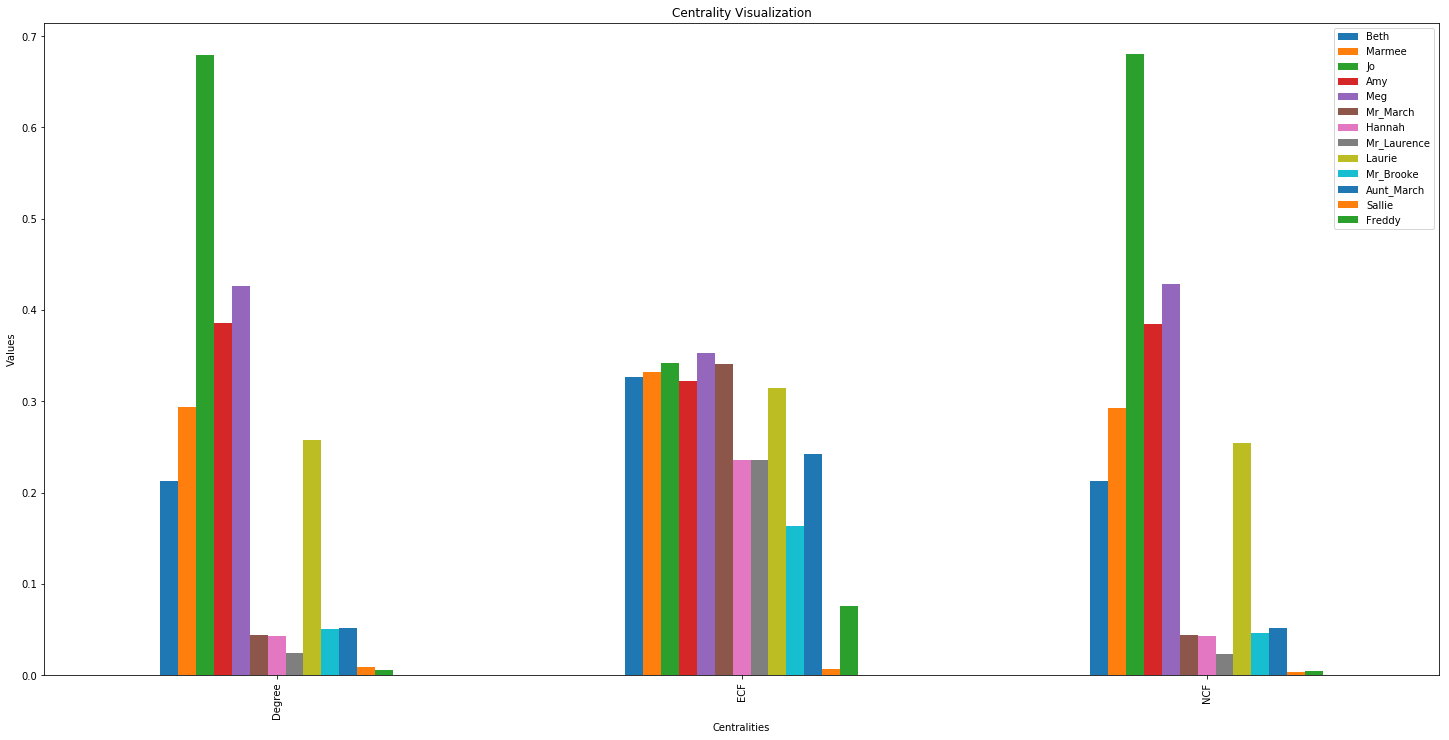

In [25]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16]),
    "Freddy":list(df_2.loc[24])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

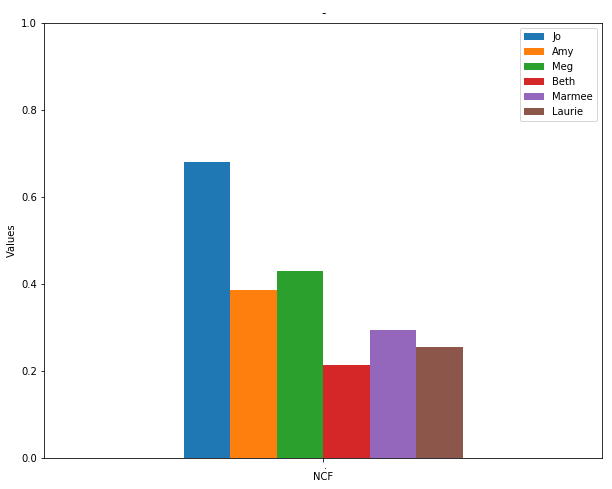

In [26]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_7

Name: 
Type: Graph
Number of nodes: 36
Number of edges: 83
Average degree:   4.6111


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


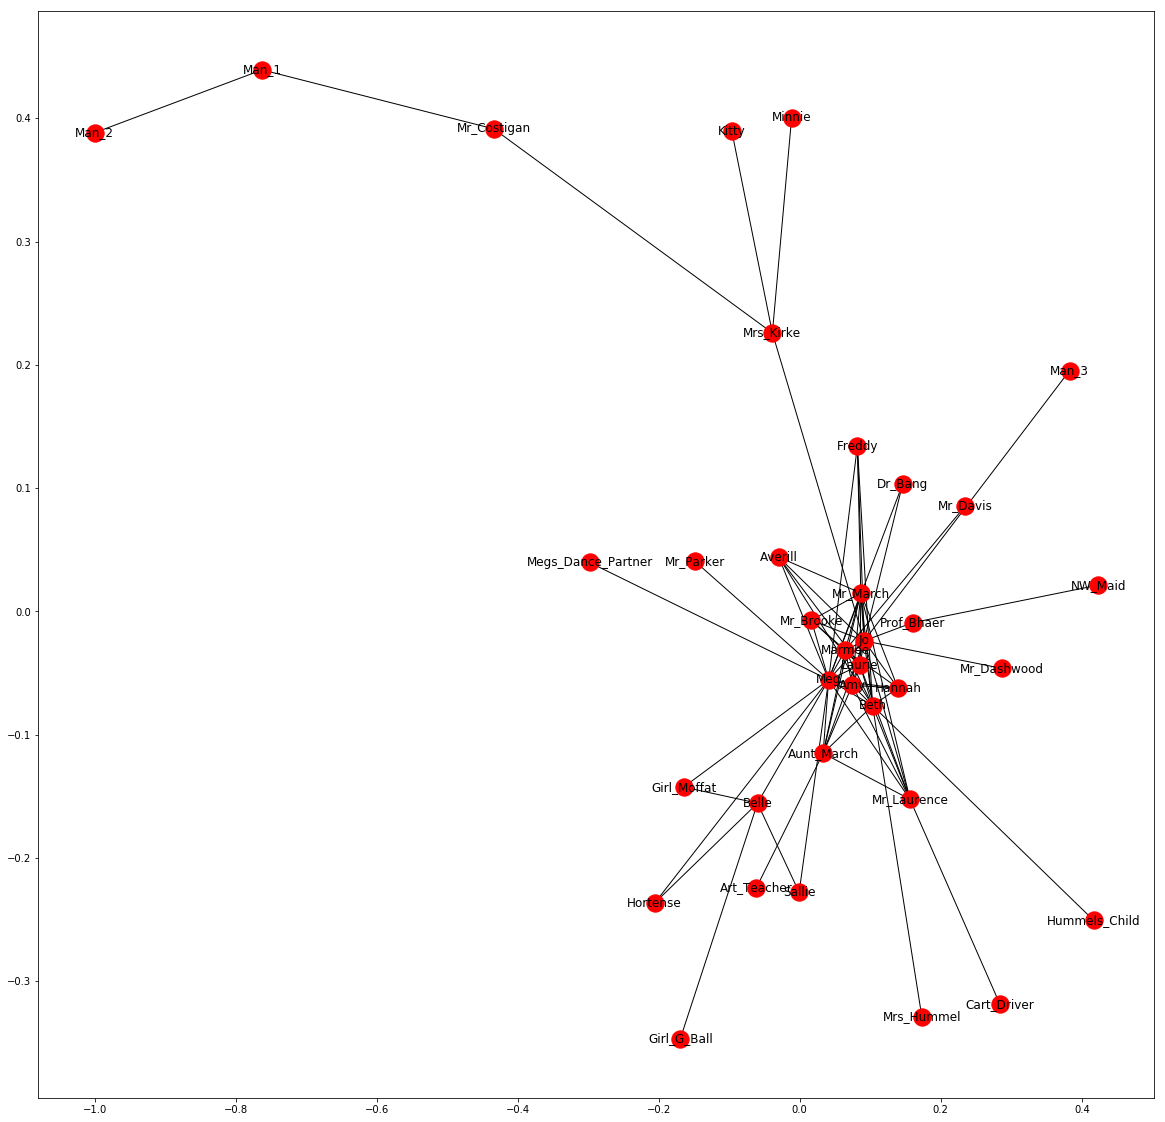

                 Nodes  Degree       ECF           NCF
0                 Beth   233.0  0.857843  8.004010e-02
1               Marmee   305.0  0.869748  1.045492e-01
2                   Jo   792.0  0.948880  2.755632e-01
3                  Amy   400.0  0.845938  1.377021e-01
4                  Meg   442.0  0.923669  1.533530e-01
5             Mr_March    46.0  0.892157  1.580191e-02
6               Hannah    45.0  0.620448  1.519358e-02
7          Mr_Laurence    25.0  0.621148  8.428617e-03
8               Laurie   267.0  0.824230  9.119604e-02
9          Cart_Driver     3.0  0.002101  1.838971e-05
10               Belle    31.0  0.026611  3.466092e-03
11         Girl_G_Ball     3.0  0.002101  2.280324e-05
12  Megs_Dance_Partner     1.0  0.000700  1.083767e-04
13           Mr_Brooke    52.0  0.425070  1.653701e-02
14          Aunt_March    54.0  0.637955  1.845738e-02
15            Mr_Davis     4.0  0.002801  2.991393e-04
16              Sallie     9.0  0.018207  1.006285e-03
17        

In [15]:
lw_7 = nx.read_weighted_edgelist('lw_m_7.txt', delimiter=',')
print(nx.info(lw_7))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_7)
plt.show()

#Weighted Centralities
w_deg = lw_7.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_7)  #ECF
w_ecf = weighted_ECF(lw_7, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_7) #NCF
w_ncf = weighted_cness(lw_7,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [16]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.211,0.325,0.210
1,0.276,0.329,0.274
2,0.718,0.359,0.723
3,0.363,0.320,0.361
4,0.401,0.350,0.402
5,0.042,0.338,0.041
6,0.041,0.235,0.040
7,0.023,0.235,0.022
8,0.242,0.312,0.239
9,0.003,0.001,0.000


Text(0, 0.5, 'Values')

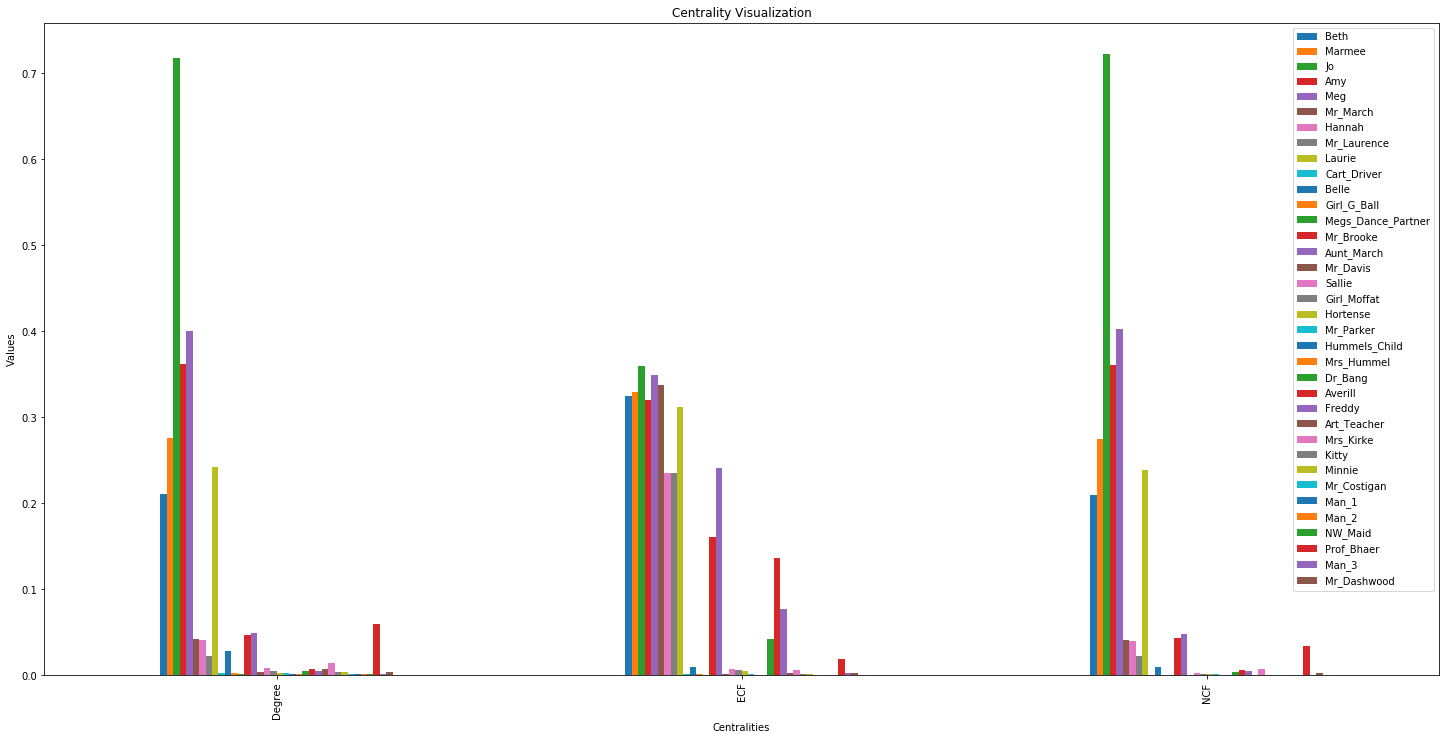

In [28]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19]),
    "Hummels_Child":list(df_2.loc[20]),
    "Mrs_Hummel":list(df_2.loc[21]),
    "Dr_Bang":list(df_2.loc[22]),
    "Averill":list(df_2.loc[23]),
    "Freddy":list(df_2.loc[24]),
    "Art_Teacher":list(df_2.loc[25]),
    "Mrs_Kirke":list(df_2.loc[26]),
    "Kitty":list(df_2.loc[27]),
    "Minnie":list(df_2.loc[28]),
    "Mr_Costigan":list(df_2.loc[29]),
    "Man_1":list(df_2.loc[30]),
    "Man_2":list(df_2.loc[31]),
    "NW_Maid":list(df_2.loc[32]),
    "Prof_Bhaer":list(df_2.loc[33]),
    "Man_3":list(df_2.loc[34]),
    "Mr_Dashwood":list(df_2.loc[35])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

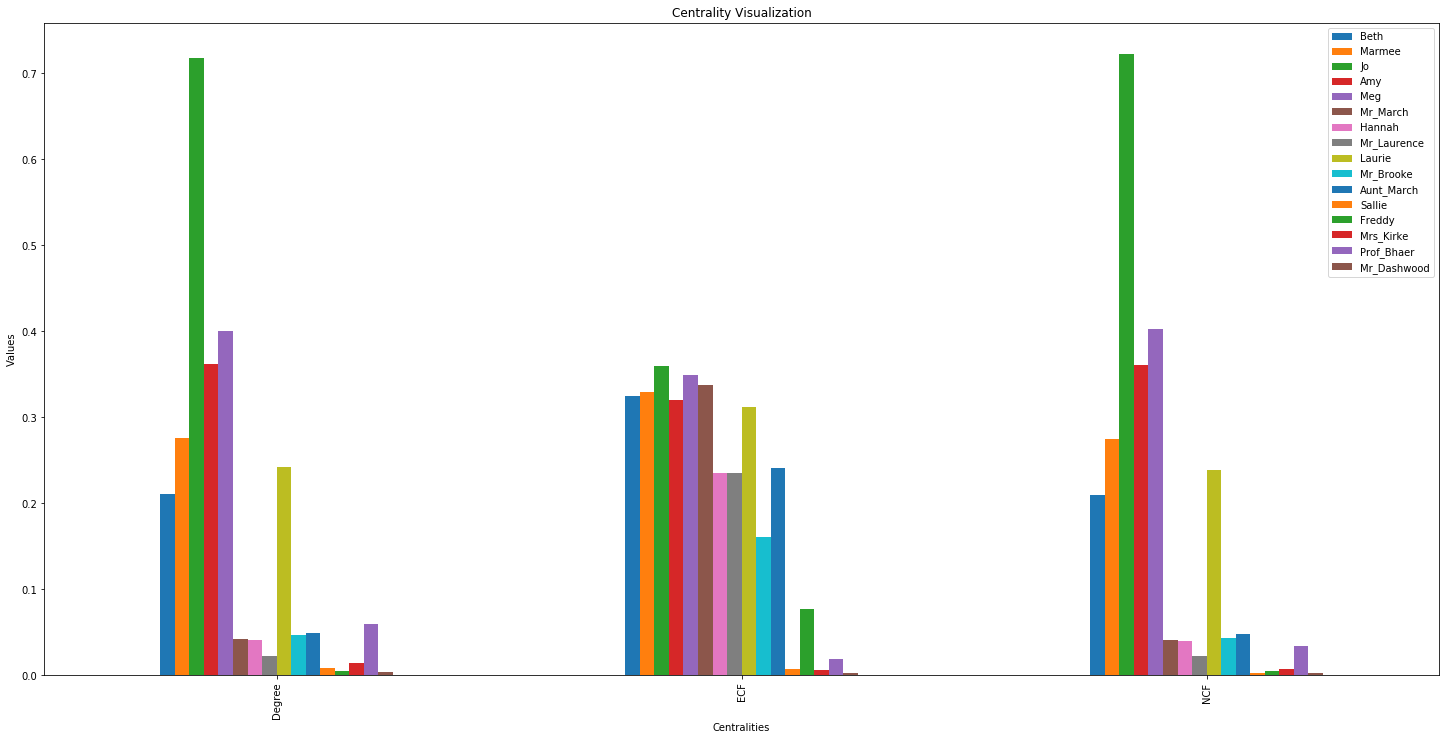

In [29]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16]),
    "Freddy":list(df_2.loc[24]),
    "Mrs_Kirke":list(df_2.loc[26]),
    "Prof_Bhaer":list(df_2.loc[33]),
    "Mr_Dashwood":list(df_2.loc[35])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

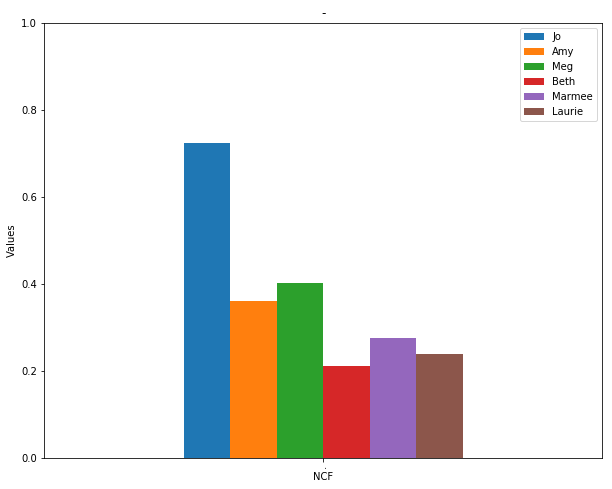

In [30]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_8

Name: 
Type: Graph
Number of nodes: 42
Number of edges: 100
Average degree:   4.7619


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


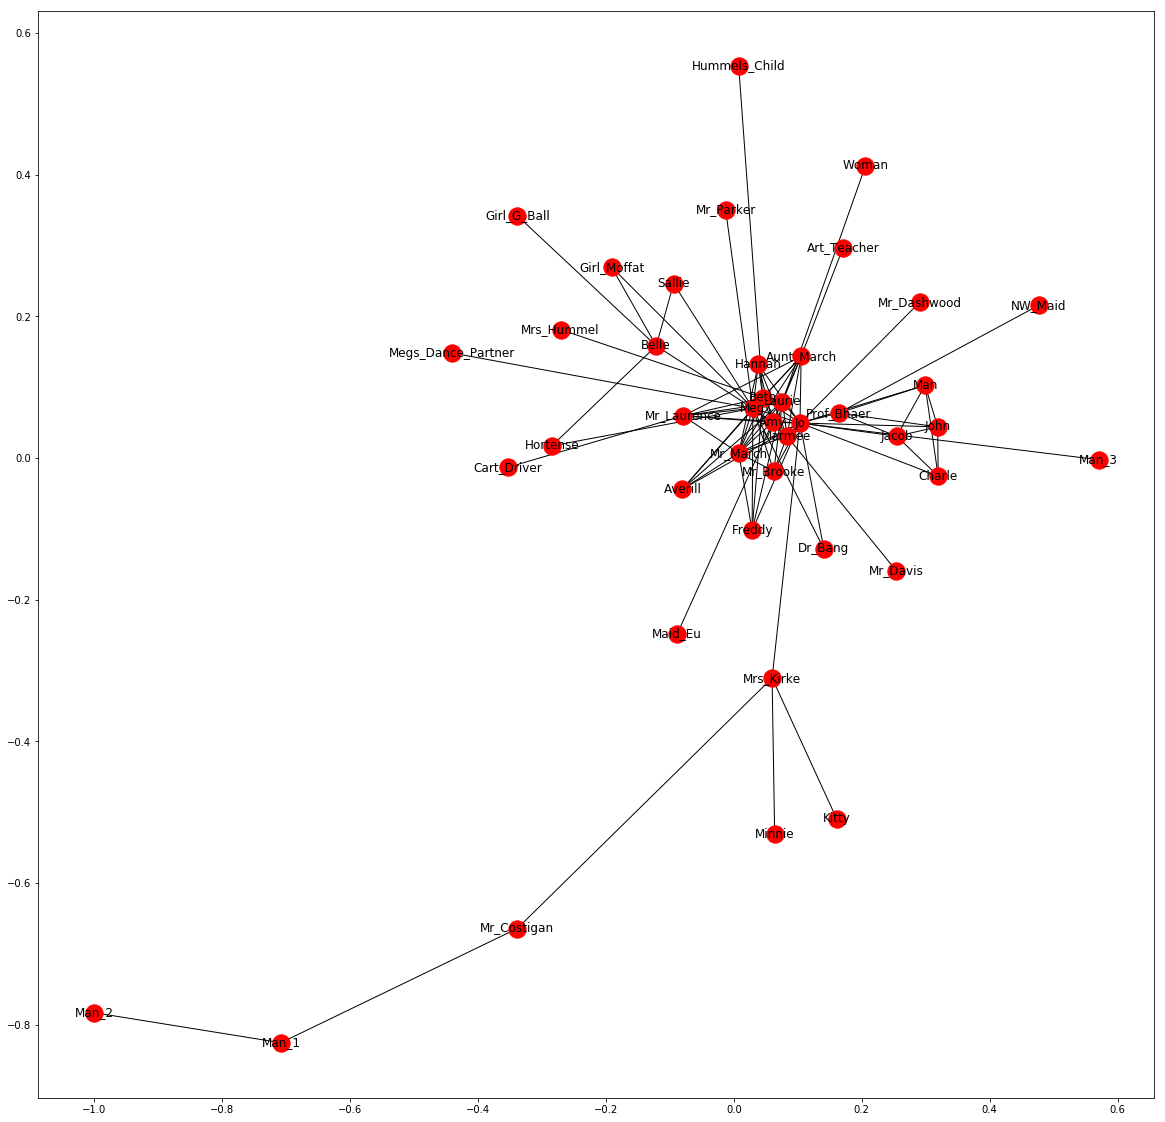

                 Nodes  Degree       ECF           NCF
0                 Beth   233.0  0.786585  6.843769e-02
1               Marmee   305.0  0.794512  8.941571e-02
2                   Jo   902.0  0.953049  2.734909e-01
3                  Amy   458.0  0.775000  1.347810e-01
4                  Meg   442.0  0.843902  1.309764e-01
5             Mr_March    46.0  0.816463  1.351130e-02
6               Hannah    45.0  0.540244  1.292478e-02
7          Mr_Laurence    25.0  0.578049  7.222264e-03
8               Laurie   331.0  0.790244  9.722264e-02
9          Cart_Driver     3.0  0.001829  1.394259e-05
10               Belle    31.0  0.023171  2.627900e-03
11         Girl_G_Ball     3.0  0.001829  1.728882e-05
12  Megs_Dance_Partner     1.0  0.000610  8.216835e-05
13           Mr_Brooke    52.0  0.370122  1.421996e-02
14          Aunt_March    62.0  0.751220  1.821089e-02
15            Mr_Davis     4.0  0.002439  2.267995e-04
16              Sallie     9.0  0.015854  7.629387e-04
17        

In [17]:
lw_8 = nx.read_weighted_edgelist('lw_m_8.txt', delimiter=',')
print(nx.info(lw_8))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_8)
plt.show()

#Weighted Centralities
w_deg = lw_8.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_8)  #ECF
w_ecf = weighted_ECF(lw_8, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_8) #NCF
w_ncf = weighted_cness(lw_8,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [18]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.189,0.312,0.187
1,0.248,0.315,0.244
2,0.733,0.378,0.747
3,0.372,0.307,0.368
4,0.359,0.335,0.358
5,0.037,0.324,0.037
6,0.037,0.214,0.035
7,0.020,0.229,0.020
8,0.269,0.313,0.266
9,0.002,0.001,0.000


Text(0, 0.5, 'Values')

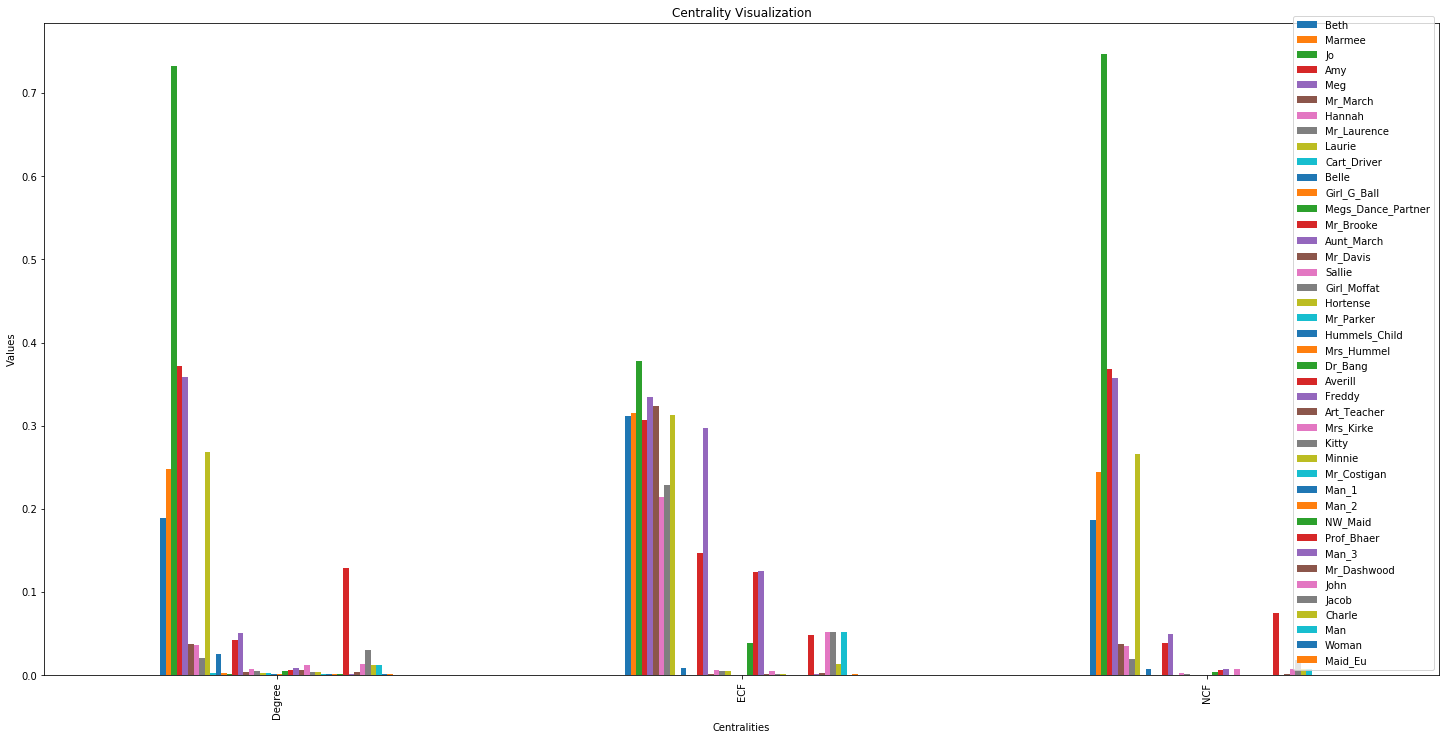

In [32]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19]),
    "Hummels_Child":list(df_2.loc[20]),
    "Mrs_Hummel":list(df_2.loc[21]),
    "Dr_Bang":list(df_2.loc[22]),
    "Averill":list(df_2.loc[23]),
    "Freddy":list(df_2.loc[24]),
    "Art_Teacher":list(df_2.loc[25]),
    "Mrs_Kirke":list(df_2.loc[26]),
    "Kitty":list(df_2.loc[27]),
    "Minnie":list(df_2.loc[28]),
    "Mr_Costigan":list(df_2.loc[29]),
    "Man_1":list(df_2.loc[30]),
    "Man_2":list(df_2.loc[31]),
    "NW_Maid":list(df_2.loc[32]),
    "Prof_Bhaer":list(df_2.loc[33]),
    "Man_3":list(df_2.loc[34]),
    "Mr_Dashwood":list(df_2.loc[35]),
    "John":list(df_2.loc[36]),
    "Jacob":list(df_2.loc[37]),
    "Charle":list(df_2.loc[38]),
    "Man":list(df_2.loc[39]),
    "Woman":list(df_2.loc[40]),
    "Maid_Eu":list(df_2.loc[41])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

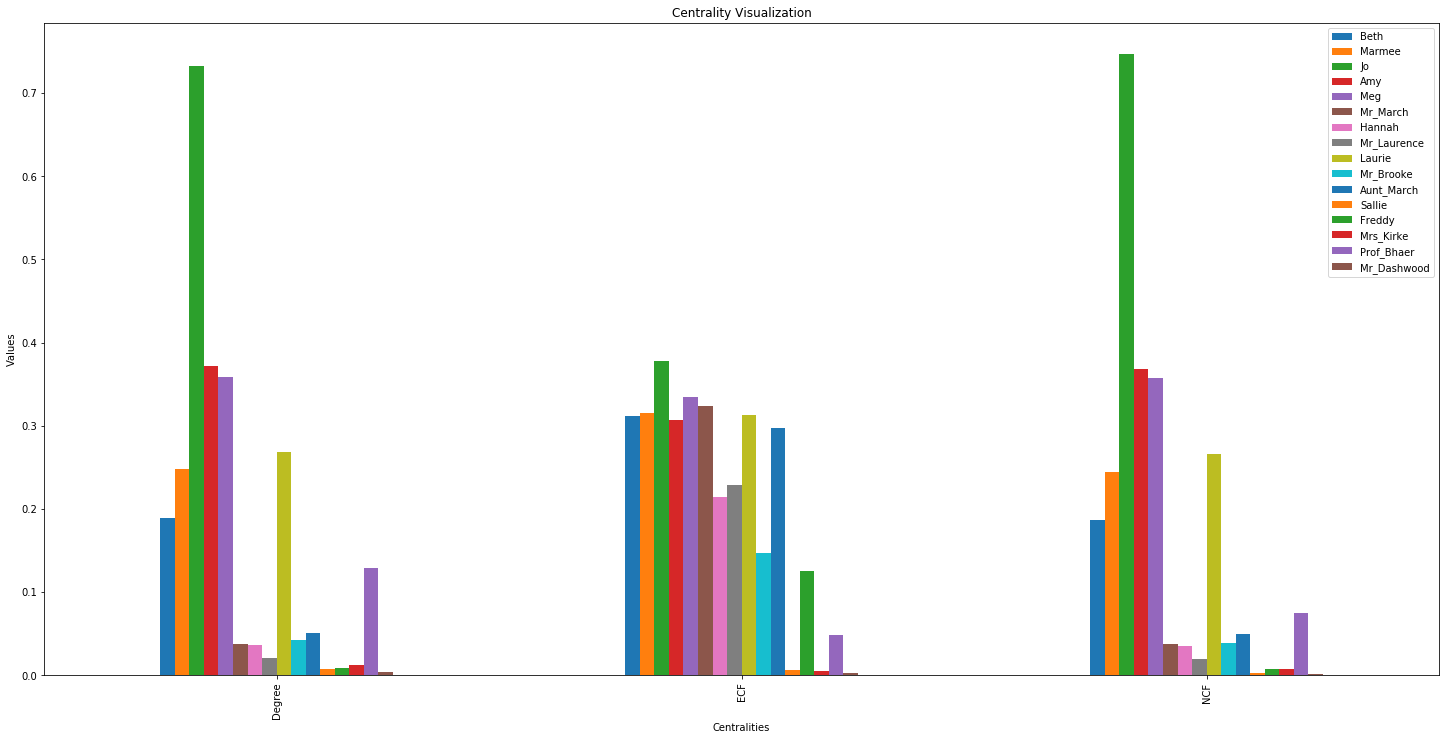

In [33]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16]),
    "Freddy":list(df_2.loc[24]),
    "Mrs_Kirke":list(df_2.loc[26]),
    "Prof_Bhaer":list(df_2.loc[33]),
    "Mr_Dashwood":list(df_2.loc[35])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

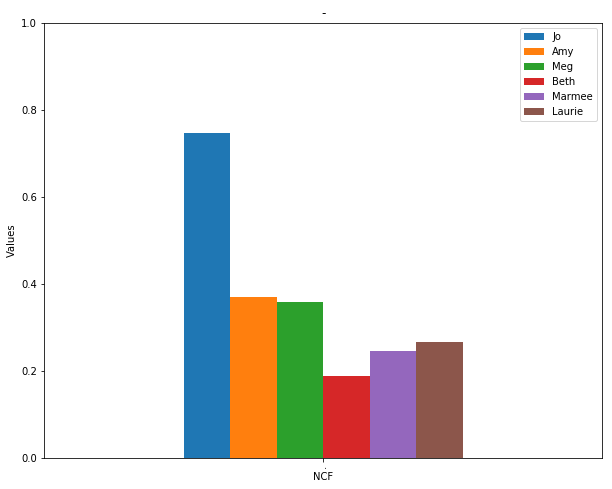

In [34]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_9

Name: 
Type: Graph
Number of nodes: 44
Number of edges: 105
Average degree:   4.7727


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


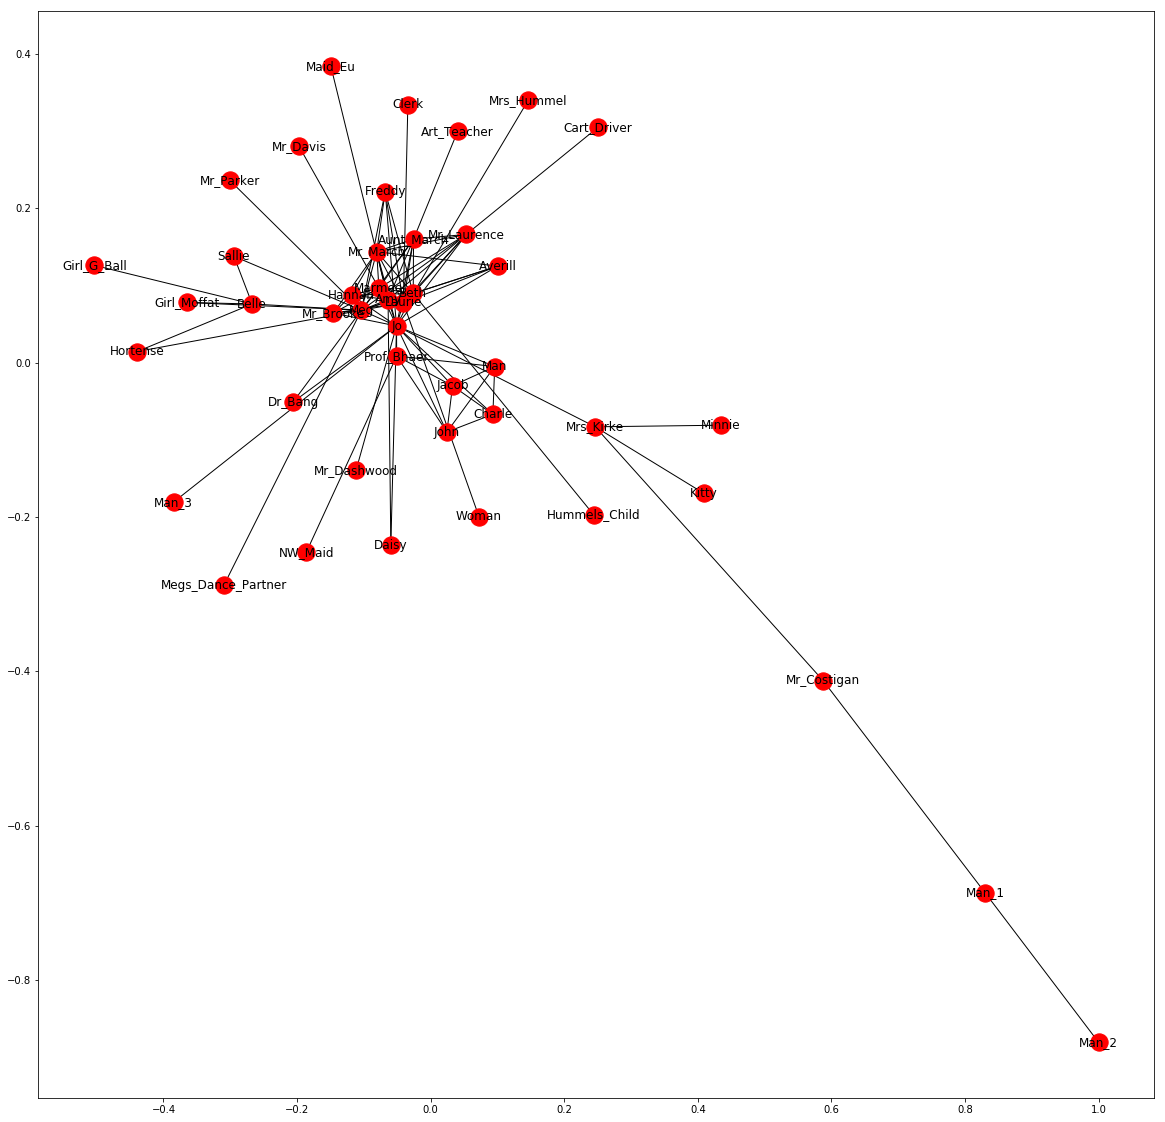

                 Nodes  Degree       ECF           NCF
0                 Beth   264.0  0.780554  6.936338e-02
1               Marmee   339.0  0.802281  8.906889e-02
2                   Jo  1078.0  0.956545  2.916624e-01
3                  Amy   487.0  0.771320  1.281700e-01
4                  Meg   471.0  0.834329  1.247234e-01
5             Mr_March    52.0  0.809886  1.366248e-02
6               Hannah    63.0  0.578490  1.622734e-02
7          Mr_Laurence    26.0  0.737099  6.827407e-03
8               Laurie   355.0  0.778381  9.327273e-02
9          Cart_Driver     3.0  0.001630  1.150687e-05
10               Belle    31.0  0.020641  2.218022e-03
11         Girl_G_Ball     3.0  0.001630  1.371972e-05
12  Megs_Dance_Partner     1.0  0.000543  6.948376e-05
13           Mr_Brooke    57.0  0.397610  1.415212e-02
14          Aunt_March    62.0  0.739815  1.628074e-02
15            Mr_Davis     4.0  0.002173  2.000424e-04
16              Sallie     9.0  0.014123  6.439419e-04
17        

In [19]:
lw_9 = nx.read_weighted_edgelist('lw_m_9.txt', delimiter=',')
print(nx.info(lw_9))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_9)
plt.show()

#Weighted Centralities
w_deg = lw_9.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_9)  #ECF
w_ecf = weighted_ECF(lw_9, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_9) #NCF
w_ncf = weighted_cness(lw_9,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [20]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.187,0.304,0.185
1,0.240,0.312,0.238
2,0.764,0.372,0.778
3,0.345,0.300,0.342
4,0.334,0.324,0.333
5,0.037,0.315,0.036
6,0.045,0.225,0.043
7,0.018,0.287,0.018
8,0.252,0.303,0.249
9,0.002,0.001,0.000


Text(0, 0.5, 'Values')

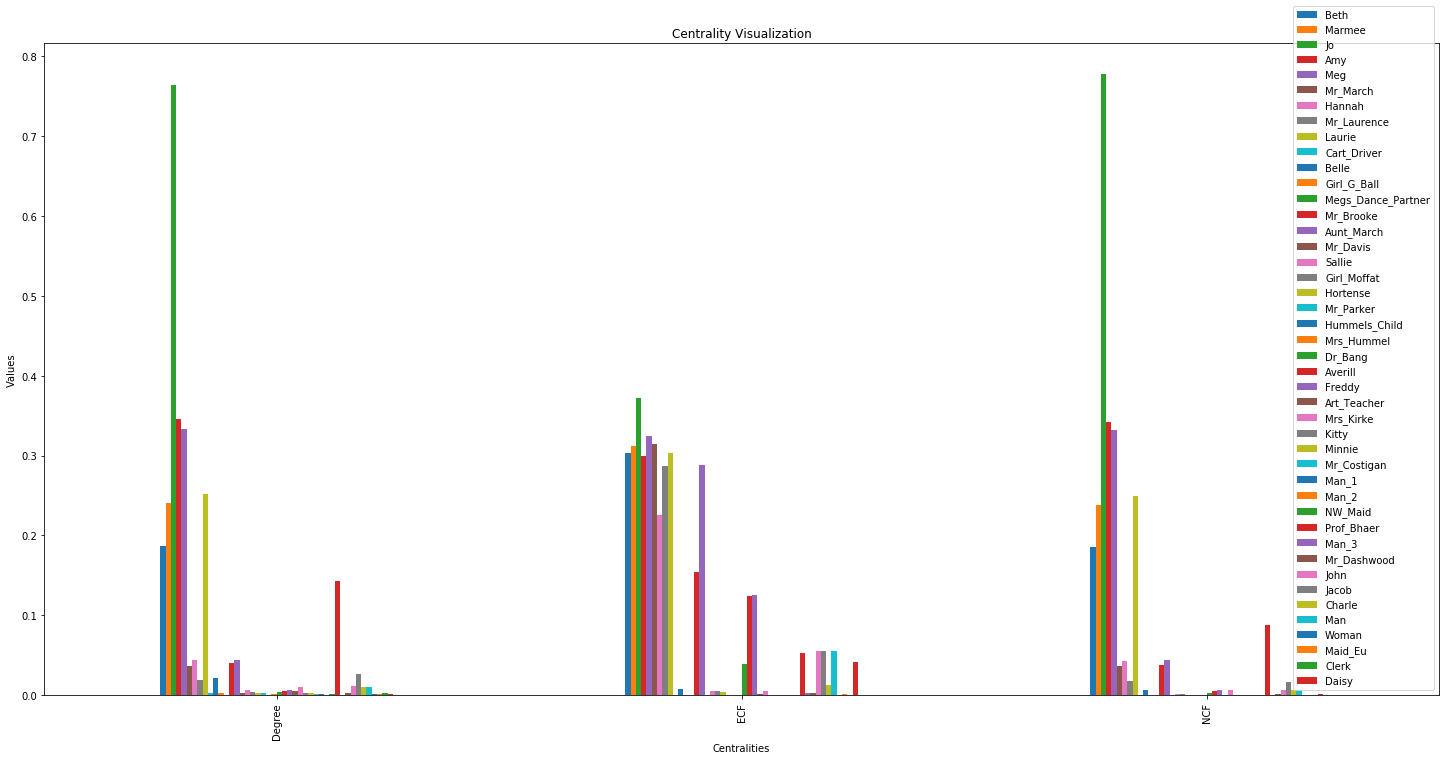

In [36]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Cart_Driver":list(df_2.loc[9]),
    "Belle":list(df_2.loc[10]),
    "Girl_G_Ball":list(df_2.loc[11]),
    "Megs_Dance_Partner":list(df_2.loc[12]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Sallie":list(df_2.loc[16]),
    "Girl_Moffat":list(df_2.loc[17]),
    "Hortense":list(df_2.loc[18]),
    "Mr_Parker":list(df_2.loc[19]),
    "Hummels_Child":list(df_2.loc[20]),
    "Mrs_Hummel":list(df_2.loc[21]),
    "Dr_Bang":list(df_2.loc[22]),
    "Averill":list(df_2.loc[23]),
    "Freddy":list(df_2.loc[24]),
    "Art_Teacher":list(df_2.loc[25]),
    "Mrs_Kirke":list(df_2.loc[26]),
    "Kitty":list(df_2.loc[27]),
    "Minnie":list(df_2.loc[28]),
    "Mr_Costigan":list(df_2.loc[29]),
    "Man_1":list(df_2.loc[30]),
    "Man_2":list(df_2.loc[31]),
    "NW_Maid":list(df_2.loc[32]),
    "Prof_Bhaer":list(df_2.loc[33]),
    "Man_3":list(df_2.loc[34]),
    "Mr_Dashwood":list(df_2.loc[35]),
    "John":list(df_2.loc[36]),
    "Jacob":list(df_2.loc[37]),
    "Charle":list(df_2.loc[38]),
    "Man":list(df_2.loc[39]),
    "Woman":list(df_2.loc[40]),
    "Maid_Eu":list(df_2.loc[41]),
    "Clerk":list(df_2.loc[42]),
    "Daisy":list(df_2.loc[43])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

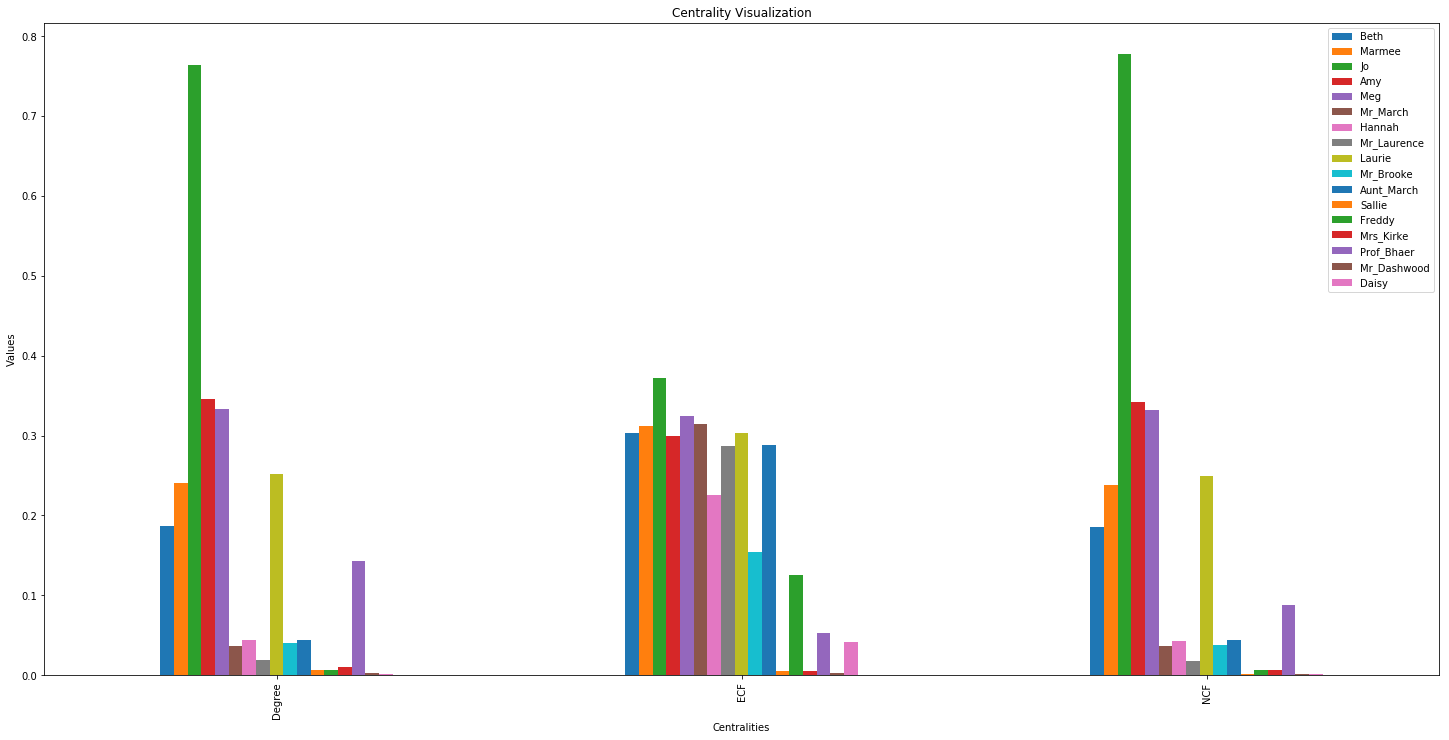

In [37]:
plotdata = pd.DataFrame({

    "Beth":list(df_2.loc[0]),
    "Marmee":list(df_2.loc[1]),
    "Jo":list(df_2.loc[2]),
    "Amy":list(df_2.loc[3]),    
    "Meg":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[6]),
    "Mr_Laurence":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Mr_Brooke":list(df_2.loc[13]),
    "Aunt_March":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[16]),
    "Freddy":list(df_2.loc[24]),
    "Mrs_Kirke":list(df_2.loc[26]),
    "Prof_Bhaer":list(df_2.loc[33]),
    "Mr_Dashwood":list(df_2.loc[35]),
    "Daisy":list(df_2.loc[43])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

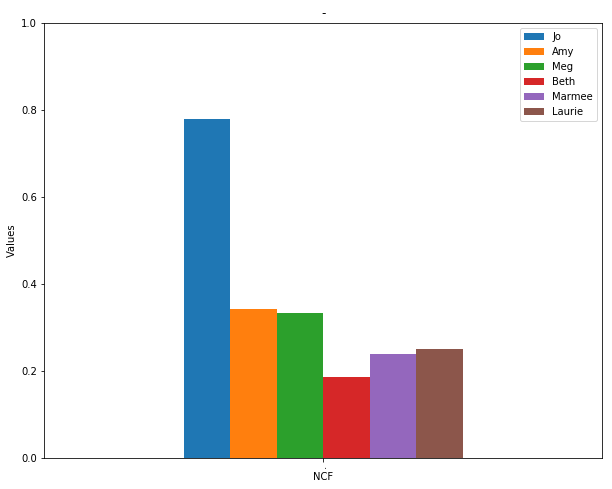

In [38]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[2][2],
    "Amy":df_2.loc[3][2],
    "Meg":df_2.loc[4][2],
    "Beth":df_2.loc[0][2],
    "Marmee":df_2.loc[1][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

In [39]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9']

jo = [0.644716,0.656585,0.662605,0.653429,0.647172,0.680565,0.722592,0.747054,7.777827e-01]
amy = [0.376042,0.410370,0.389631,0.410050,0.401529,0.384967,0.361088,0.368161,3.417937e-01]
meg = [0.479923,0.480922,0.466412,0.470315,0.465585,0.428942,0.402128,0.357769,3.326025e-01]
beth = [0.287158,0.208035,0.203229,0.207325,0.229020,0.212210,0.209884,0.186941,1.849729e-01]
marmee = [0.281314,0.284979,0.315847,0.294863,0.304945,0.292200,0.274153,0.244244,2.375220e-01]
laurie = [0.221560,0.201625,0.211673,0.218308,0.217303,0.254819,0.239138,0.265569,2.487325e-01]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Jo' : jo,'Amy' : amy, 'Meg' : meg, 'Beth' : beth, 'Marmee' : marmee, 'Laurie' : laurie})
df_pop_density

,Timestamp,Jo,Amy,Meg,Beth,Marmee,Laurie
0,t1,0.644716,0.376042,0.479923,0.287158,0.281314,0.221560
1,t2,0.656585,0.410370,0.480922,0.208035,0.284979,0.201625
2,t3,0.662605,0.389631,0.466412,0.203229,0.315847,0.211673
3,t4,0.653429,0.410050,0.470315,0.207325,0.294863,0.218308
4,t5,0.647172,0.401529,0.465585,0.229020,0.304945,0.217303
5,t6,0.680565,0.384967,0.428942,0.212210,0.292200,0.254819
6,t7,0.722592,0.361088,0.402128,0.209884,0.274153,0.239138
7,t8,0.747054,0.368161,0.357769,0.186941,0.244244,0.265569
8,t9,0.777783,0.341794,0.332603,0.184973,0.237522,0.248732


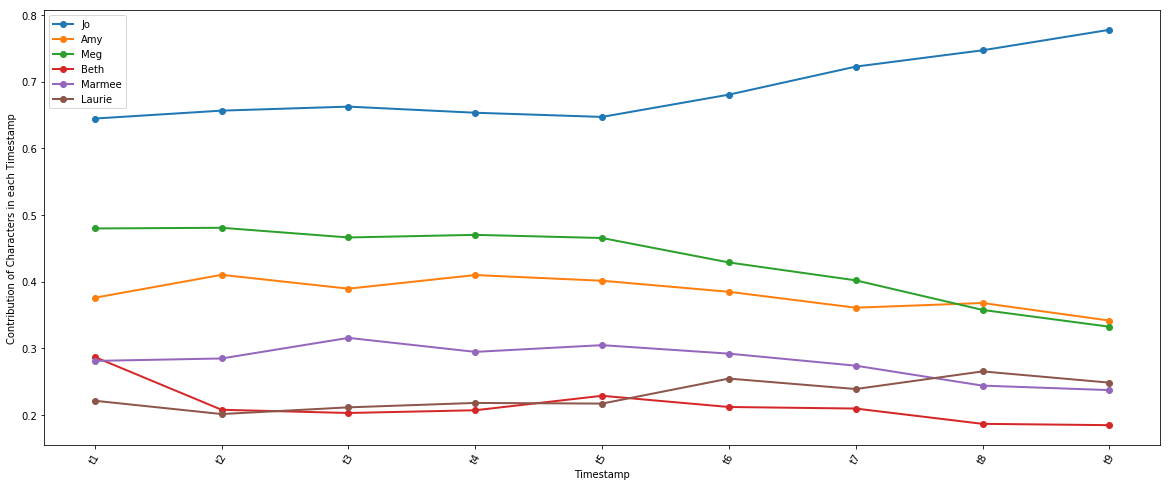

In [40]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[20, 8])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Jo'], marker='o', linewidth=2, label='Jo')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Amy'], marker='o', linewidth=2, label='Amy')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Meg'], marker='o', linewidth=2, label='Meg')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Beth'], marker='o', linewidth=2, label='Beth')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Marmee'], marker='o', linewidth=2, label='Marmee')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Laurie'], marker='o', linewidth=2, label='Laurie')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Contribution of Characters in each Timestamp')
plt.legend()
plt.show()

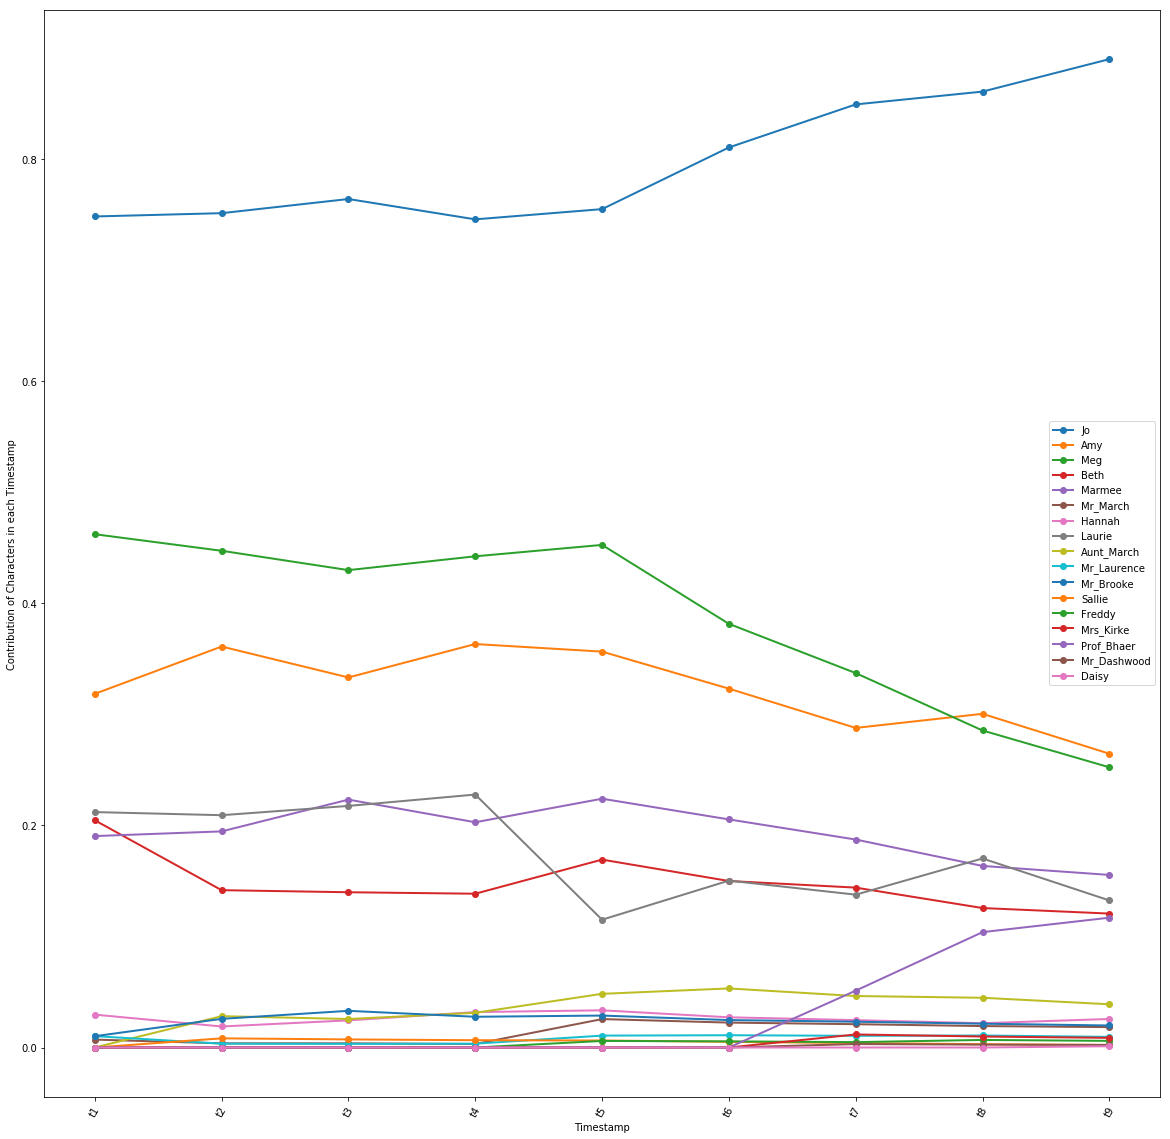

In [63]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[20, 20])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Jo'], marker='o', linewidth=2, label='Jo')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Amy'], marker='o', linewidth=2, label='Amy')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Meg'], marker='o', linewidth=2, label='Meg')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Beth'], marker='o', linewidth=2, label='Beth')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Marmee'], marker='o', linewidth=2, label='Marmee')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mr_March'], marker='o', linewidth=2, label='Mr_March')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Hannah'], marker='o', linewidth=2, label='Hannah')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Laurie'], marker='o', linewidth=2, label='Laurie')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Aunt_March'], marker='o', linewidth=2, label='Aunt_March')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mr_Laurence'], marker='o', linewidth=2, label='Mr_Laurence')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mr_Brooke'], marker='o', linewidth=2, label='Mr_Brooke')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Sallie'], marker='o', linewidth=2, label='Sallie')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Freddy'], marker='o', linewidth=2, label='Freddy')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mrs_Kirke'], marker='o', linewidth=2, label='Mrs_Kirke')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Prof_Bhaer'], marker='o', linewidth=2, label='Prof_Bhaer')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mr_Dashwood'], marker='o', linewidth=2, label='Mr_Dashwood')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Daisy'], marker='o', linewidth=2, label='Daisy')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Contribution of Characters in each Timestamp')
plt.legend()
plt.show()

In [12]:
# Reevaluate the remaining part

In [62]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva_yogmaya = [0.8181818181818182,1.4729064039408866,1.6794258373205742,1.3652450090744102]

apoorva_mrinmoyee = [0.5454545454545454,1.379310344827586,2.0050125313283207,1.4123376623376624]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Correlation_With_Yogmaya' : apoorva_yogmaya, 'Correlation_With_Mrinmoyee' : apoorva_mrinmoyee})

df_pop_density

,Timestamp,Correlation_With_Yogmaya,Correlation_With_Mrinmoyee
0,t1,0.818182,0.545455
1,t2,1.472906,1.379310
2,t3,1.679426,2.005013
3,t4,1.365245,1.412338


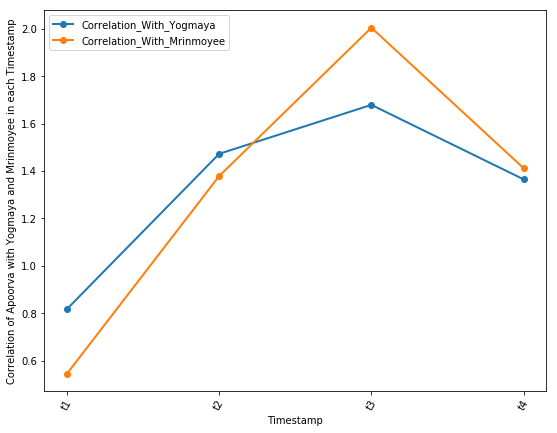

In [63]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Yogmaya'], marker='o', linewidth=2, label='Correlation_With_Yogmaya')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Mrinmoyee'], marker='o', linewidth=2, label='Correlation_With_Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Correlation of Apoorva with Yogmaya and Mrinmoyee in each Timestamp')
plt.legend()
plt.show()